In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve, f1_score, precision_score, recall_score, roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from matplotlib.patches import Patch
import lime.lime_tabular
import random

## Analyse exploratoire

In [2]:
Evaluation = pd.read_csv("extrait_eval.csv")
Sirh = pd.read_csv("extrait_sirh.csv")
Sondage = pd.read_csv("extrait_sondage.csv")

In [3]:
Evaluation.head()

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %
3,4,3,1,3,3,3,E_5,3,Oui,11 %
4,1,3,1,2,4,3,E_7,3,Non,12 %


In [4]:
Evaluation.duplicated().sum()

np.int64(0)

Il n'y a pas de doublons dans ce dataframe.

In [5]:
Evaluation.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   satisfaction_employee_environnement        1470 non-null   int64
 1   note_evaluation_precedente                 1470 non-null   int64
 2   niveau_hierarchique_poste                  1470 non-null   int64
 3   satisfaction_employee_nature_travail       1470 non-null   int64
 4   satisfaction_employee_equipe               1470 non-null   int64
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64
 6   eval_number                                1470 non-null   str  
 7   note_evaluation_actuelle                   1470 non-null   int64
 8   heure_supplementaires                      1470 non-null   str  
 9   augementation_salaire_precedente           1470 non-null   str  
dtypes: int64(7), str(3)
memory usage: 115.0 KB


In [6]:
Evaluation.nunique()

satisfaction_employee_environnement             4
note_evaluation_precedente                      4
niveau_hierarchique_poste                       5
satisfaction_employee_nature_travail            4
satisfaction_employee_equipe                    4
satisfaction_employee_equilibre_pro_perso       4
eval_number                                  1470
note_evaluation_actuelle                        2
heure_supplementaires                           2
augementation_salaire_precedente               15
dtype: int64

**structure**: Tableau de 1470 lignes pour 10 colonnes.  
Chaque ligne correspond a un employé, et chaque colonne fourni les informations pour l'employé:
- Niveau satisfaction de l'environnement de travail de l'employé 
- Note de l'employé lors de l'évaluation précédente
- Niveau hierarchique de l'employé
- Niveau de satisfaction vis a vis de la nature du travail demandé à l'employé
- Niveau de satisfaction de l'équipe de travai de l'employé
- Niveau de satisfaction de l'equilibre vie personnelle / vie professionnelle
- Numéro de l'évaluation (code unique par employé)
- Note de l'employé lors de l'évaluation actuelle
- l'employé a t il fait des heurs supplémentaires (oui/non)
- taux d'augmentation du salaire de l'employé par rapport à la précédente évaluation


Toutes ces variables sont catégorielles ordinales, sauf le taux d'augmentation qui est numérique, et les heures supplémentaires qui est une variable binaire.
La clé permettant d'ddentifier chaque employé est eval-number.  
Il n'y a pas de valeurs manquantes.

In [7]:
Sirh.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


In [8]:
Sirh.duplicated().sum()

np.int64(0)

Il n'y a pas de doublons dans ce dataframe.

In [9]:
Sirh.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   id_employee                     1470 non-null   int64
 1   age                             1470 non-null   int64
 2   genre                           1470 non-null   str  
 3   revenu_mensuel                  1470 non-null   int64
 4   statut_marital                  1470 non-null   str  
 5   departement                     1470 non-null   str  
 6   poste                           1470 non-null   str  
 7   nombre_experiences_precedentes  1470 non-null   int64
 8   nombre_heures_travailless       1470 non-null   int64
 9   annee_experience_totale         1470 non-null   int64
 10  annees_dans_l_entreprise        1470 non-null   int64
 11  annees_dans_le_poste_actuel     1470 non-null   int64
dtypes: int64(8), str(4)
memory usage: 137.9 KB


In [10]:
Sirh.nunique()

id_employee                       1470
age                                 43
genre                                2
revenu_mensuel                    1349
statut_marital                       3
departement                          3
poste                                9
nombre_experiences_precedentes      10
nombre_heures_travailless            1
annee_experience_totale             40
annees_dans_l_entreprise            37
annees_dans_le_poste_actuel         19
dtype: int64

**Structure**: Tableau de 1470 lignes et 12 colonnes.  
Chaque ligne correspond à un employé, et chaque colonne donne les informations:
- Identifiant de l'employé
- Âge de l'employé
- Genre de l'employé
- Revenus mensuel de l'employé
- Statut marital de l'employé
- Département professionnel de l'employé
- Poste de l'employé
- Nombre d'experiences professionnelles précédentes
- Nombre d'heures travaillées par semaines
- Années d'experiences professionnelle totale
- Années d'experiences dans l'entreprise
- Années dan sle poste actuel


La plupart de ces indicateurs sont des variables numérique discrètes, mis à part le genre, le statut marital, le département professionnel, ainsi que le poste qui sont des variables catégorielles nominales.  
La clé permettant d'identifier chaque employé est id-employee.  
Il n'y a pas de valeurs manquantes.

In [11]:
Sondage.head()

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


In [12]:
Sondage.duplicated().sum()

np.int64(0)

Il n'y a pas de doublons dans ce dataframe.

In [13]:
Sondage.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   a_quitte_l_entreprise                1470 non-null   str  
 1   nombre_participation_pee             1470 non-null   int64
 2   nb_formations_suivies                1470 non-null   int64
 3   nombre_employee_sous_responsabilite  1470 non-null   int64
 4   code_sondage                         1470 non-null   int64
 5   distance_domicile_travail            1470 non-null   int64
 6   niveau_education                     1470 non-null   int64
 7   domaine_etude                        1470 non-null   str  
 8   ayant_enfants                        1470 non-null   str  
 9   frequence_deplacement                1470 non-null   str  
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64
 11  annes_sous_responsable_actuel        1470 non-null   int64
dtypes: 

In [14]:
Sondage.nunique()

a_quitte_l_entreprise                     2
nombre_participation_pee                  4
nb_formations_suivies                     7
nombre_employee_sous_responsabilite       1
code_sondage                           1470
distance_domicile_travail                29
niveau_education                          5
domaine_etude                             6
ayant_enfants                             1
frequence_deplacement                     3
annees_depuis_la_derniere_promotion      16
annes_sous_responsable_actuel            18
dtype: int64

**Structure:** Tableau de 1470 lignes et 12 colonnes.
chaque ligne correspond à un employé, et les colonnes donnent les informations:
- L'employé a-t-il quitté l'entreprise
- Nombre de fois que l'employé a allimenté son plan d'épargne entreprise
- Nombre de formations suivies
- Nombre d'employés sous sa responsabilité 
- code d'iddentification du sondage
- distance entre le domicile de l'employé et son lieu de travail
- niveau d'éducation de l'employé
- domaine d'étude de l'employé
- l'employé a-t-il des enfants
- fréquence de déplacement de l'employé
- Nombre d'années écoulées depuis la dernière prommotion de l'employé
- Nombre d'années passées sous les ordres de son responsable actuelles


La plupart de ces indicateurs sont des variables numériques discrètes, hormis le domaine d'étude, la fréquence de déplacement, le fait d'avoir des enfants ou non, et le fait d'avoir quitté l'entreprise ou non, qui sont des variables catégorielles.
La clé permettant d'dentifier chaque employé est code-sondage.  
Il n'y a pas de valeurs manquantes.

In [15]:
(Sondage["code_sondage"]== Sirh["id_employee"]).all()

np.True_

Les deux clées code_sondage et id_employee sont identiques on peut donc faire une jointure sur ces deux tableaux.

In [16]:
Data = Sirh.merge(Sondage, left_on="id_employee", right_on="code_sondage")
Data = Data.drop(columns=["code_sondage"])
Data.head(1)

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,...,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,...,0,0,1,1,2,Infra & Cloud,Y,Occasionnel,0,5


In [17]:
Data.shape

(1470, 23)

Verifions si la clée de Evaluation, eval_number est identique aux deux autres.  

In [18]:
Evaluation["eval_number"] = Evaluation["eval_number"].str.replace("E_", "").astype(int)
(Evaluation["eval_number"]== Sirh["id_employee"]).all()

np.True_

Les deux clées eval_number et id_employee sont identiques on peut donc faire une jointure sur ces deux tableaux.

In [19]:
Data = Data.merge(Evaluation, left_on="id_employee", right_on = "eval_number")
Data = Data.drop(columns=["eval_number"])
Data.head(1)

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,...,annes_sous_responsable_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,...,5,2,3,2,4,1,1,3,Oui,11 %


In [20]:
Data.shape

(1470, 32)

On a bien nos 1470 lignes.

On peut d'ores et déjà supprimer la clé id_employee, puisque cet indicateur n'apportera rien aus modèles.

In [21]:
Data.drop(["id_employee"], axis = 1, inplace = True)
Data.shape

(1470, 31)

In [22]:
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   age                                        1470 non-null   int64
 1   genre                                      1470 non-null   str  
 2   revenu_mensuel                             1470 non-null   int64
 3   statut_marital                             1470 non-null   str  
 4   departement                                1470 non-null   str  
 5   poste                                      1470 non-null   str  
 6   nombre_experiences_precedentes             1470 non-null   int64
 7   nombre_heures_travailless                  1470 non-null   int64
 8   annee_experience_totale                    1470 non-null   int64
 9   annees_dans_l_entreprise                   1470 non-null   int64
 10  annees_dans_le_poste_actuel                1470 non-null   

In [23]:
Data["augementation_salaire_precedente"].unique()

<StringArray>
['11 %', '23 %', '15 %', '12 %', '13 %', '20 %', '22 %', '21 %', '17 %',
 '14 %', '16 %', '18 %', '19 %', '24 %', '25 %']
Length: 15, dtype: str

On remarque que la variable augementation_salaire_precedente est une chaine de caractère, transformons la en entier.

In [24]:
Data["augementation_salaire_precedente"] = Data["augementation_salaire_precedente"].str.replace("%", "", regex = False).astype("int64")
Data["augementation_salaire_precedente"].unique()

array([11, 23, 15, 12, 13, 20, 22, 21, 17, 14, 16, 18, 19, 24, 25])

In [25]:
Data["augementation_salaire_precedente"].dtype

dtype('int64')

In [26]:
Variables_Numériques = ["age", "revenu_mensuel", "nombre_experiences_precedentes",
                        "nombre_heures_travailless", "annee_experience_totale",
                        "annees_dans_l_entreprise","annees_dans_le_poste_actuel",
                        "augementation_salaire_precedente", "nombre_participation_pee",
                        "nb_formations_suivies", "nombre_employee_sous_responsabilite",
                        "distance_domicile_travail", "annees_depuis_la_derniere_promotion",
                        "annes_sous_responsable_actuel"]

Variables_categorielles = Data.loc[:,~Data.columns.isin(Variables_Numériques)].columns.tolist()

In [28]:
Variables_categorielles

['genre',
 'statut_marital',
 'departement',
 'poste',
 'a_quitte_l_entreprise',
 'niveau_education',
 'domaine_etude',
 'ayant_enfants',
 'frequence_deplacement',
 'satisfaction_employee_environnement',
 'note_evaluation_precedente',
 'niveau_hierarchique_poste',
 'satisfaction_employee_nature_travail',
 'satisfaction_employee_equipe',
 'satisfaction_employee_equilibre_pro_perso',
 'note_evaluation_actuelle',
 'heure_supplementaires']

In [27]:
Data[Variables_Numériques].describe()

,age,revenu_mensuel,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,augementation_salaire_precedente,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
count,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000
mean,36.923810,6502.931293,2.693197,80.0,11.279592,7.008163,4.229252,15.209524,0.793878,2.799320,1.0,9.192517,2.187755,4.123129
std,9.135373,4707.956783,2.498009,0.0,7.780782,6.126525,3.623137,3.659938,0.852077,1.289271,0.0,8.106864,3.222430,3.568136
min,18.000000,1009.000000,0.000000,80.0,0.000000,0.000000,0.000000,11.000000,0.000000,0.000000,1.0,1.000000,0.000000,0.000000
25%,30.000000,2911.000000,1.000000,80.0,6.000000,3.000000,2.000000,12.000000,0.000000,2.000000,1.0,2.000000,0.000000,2.000000
50%,36.000000,4919.000000,2.000000,80.0,10.000000,5.000000,3.000000,14.000000,1.000000,3.000000,1.0,7.000000,1.000000,3.000000
75%,43.000000,8379.000000,4.000000,80.0,15.000000,9.000000,7.000000,18.000000,1.000000,3.000000,1.0,14.000000,3.000000,7.000000
max,60.000000,19999.000000,9.000000,80.0,40.000000,40.000000,18.000000,25.000000,3.000000,6.000000,1.0,29.000000,15.000000,17.000000


On remarque que les indicateurs nombre_heures_travailless, et nombre_employee_sous_responsabilite sont constants, donc il n'appaorteront rien au modèle, on ne les concervera pas.  
Le reste des données semble cohérent.

supprimons les deux colonnes nombre_heures_travailless, et nombre_employee_sous_responsabilite, ainsi que dans la liste Variable-Numériqies.

In [28]:
Variables_Numériques.remove("nombre_heures_travailless")
Variables_Numériques.remove("nombre_employee_sous_responsabilite")
Data.drop(["nombre_heures_travailless","nombre_employee_sous_responsabilite"], axis =1, inplace =True)
Data.shape

(1470, 29)

On transforme nos variables categorielles en type category.

In [29]:
Data[Variables_categorielles] = Data[Variables_categorielles].astype("category")

In [30]:
Data[Variables_categorielles].describe()

,genre,statut_marital,departement,poste,a_quitte_l_entreprise,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires
count,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,9,2,5,6,1,3,4,4,5,4,4,4,2,2
top,M,Marié(e),Consulting,Cadre Commercial,Non,3,Infra & Cloud,Y,Occasionnel,3,3,1,4,3,3,3,Non
freq,882,673,961,326,1233,572,606,1470,1043,453,868,543,459,459,893,1244,1054


L'indicateur ayant_enfants, ne prend qu'une seule valeur, donc il n'apportera rien au modèle, on supprimera donc cette colonne.
Le reste des données semble cohérent.

On supprime l'indicateur ayant_enfants, et on le supprime égalemant de la liste Variables_categorielles.

In [31]:
Variables_categorielles.remove("ayant_enfants")
Data.drop("ayant_enfants", axis = 1, inplace = True)
Data.shape

(1470, 28)

Ceraines variables catégorielles nominatives seront encodées via un One-Hot encoding.
On encodera differament les variables catégorielles ordinales, ainsi que les variables binaires.

In [32]:
Variables_Nominatives = ["genre", "statut_marital", "departement", "poste", "domaine_etude"]
Variables_Ordinales = ["frequence_deplacement"]

On Cherche à prédire les départs de l'entreprise donc notre variable cible sera: a_quitte_l_entreprise.

Regardons la distribution des variables numériques.

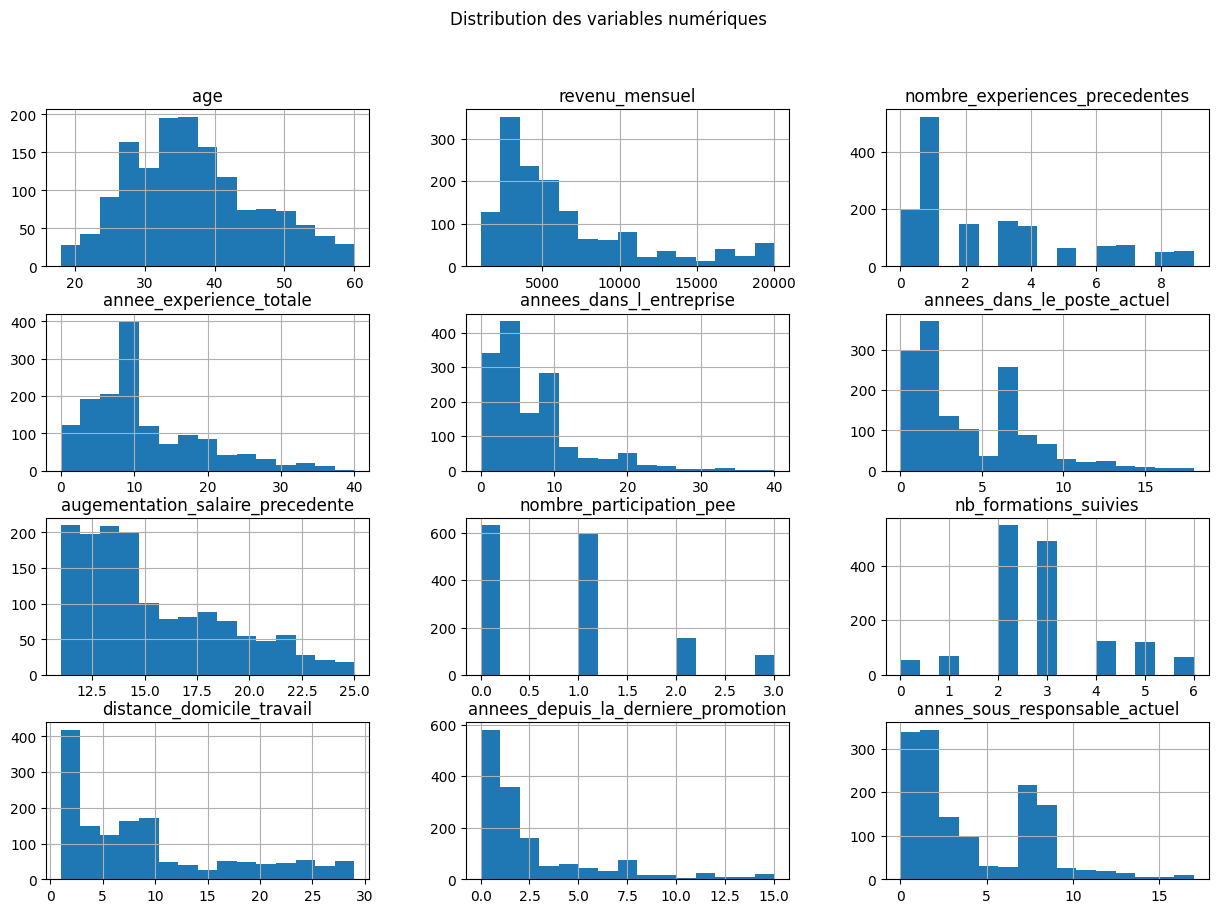

In [33]:
Data[Variables_Numériques].hist(figsize = (15,10), bins = 15)
plt.suptitle("Distribution des variables numériques")
plt.show()

- **age :** La distribution semble quasi normale
- **revenu_mensuel :** La distribution est très asymétrique, concentrée à gauche. Beaucoup de bas salaires, et peu de hauts salaires. présence possible d'outliers.
- **nombre-experience_precedente :** Distribution discrète avec beaucoup de valeurs faibles.
- **annee_experience_totale :** Distribution asymétrique à droite avec un pic aux alentours de 10 ans.
- **annees_dans_l_entreprise :** Distribution asymétrique à droite, beaucoup de nouveaux employés (lien avec le turnover)
- **annees_dans_le_poste_actuel :** Distribution asymétrique bimodale soncentrée à gauche, beaucoup de nouveaux employés et/ou de rotations internes.
- **augmentation_salaire_precedente :** Distribution étalée modérément asymétrique.
- **nombre_participation_pee :** Distribution discrète avec un pic à 0 et à 1.
- **nb_formations_suivies :** Distribution discrète centrée autour de 2-3.
- **distance_domicile_travail :** Distribution très asymétrique à droite. Quelques grandes distances et une très grande majorité de petites distances.
- **annees_depuis_la_derniere_promotion :** Distribution très asymétrique à droite
- **annes_sous_responsable_actuel :** Distribution bimodale, très asymétrique.Peut etre lié au départ de certain managers.

Regardons si il existe d'éventuelles relations entre les variables numériques et les départs.

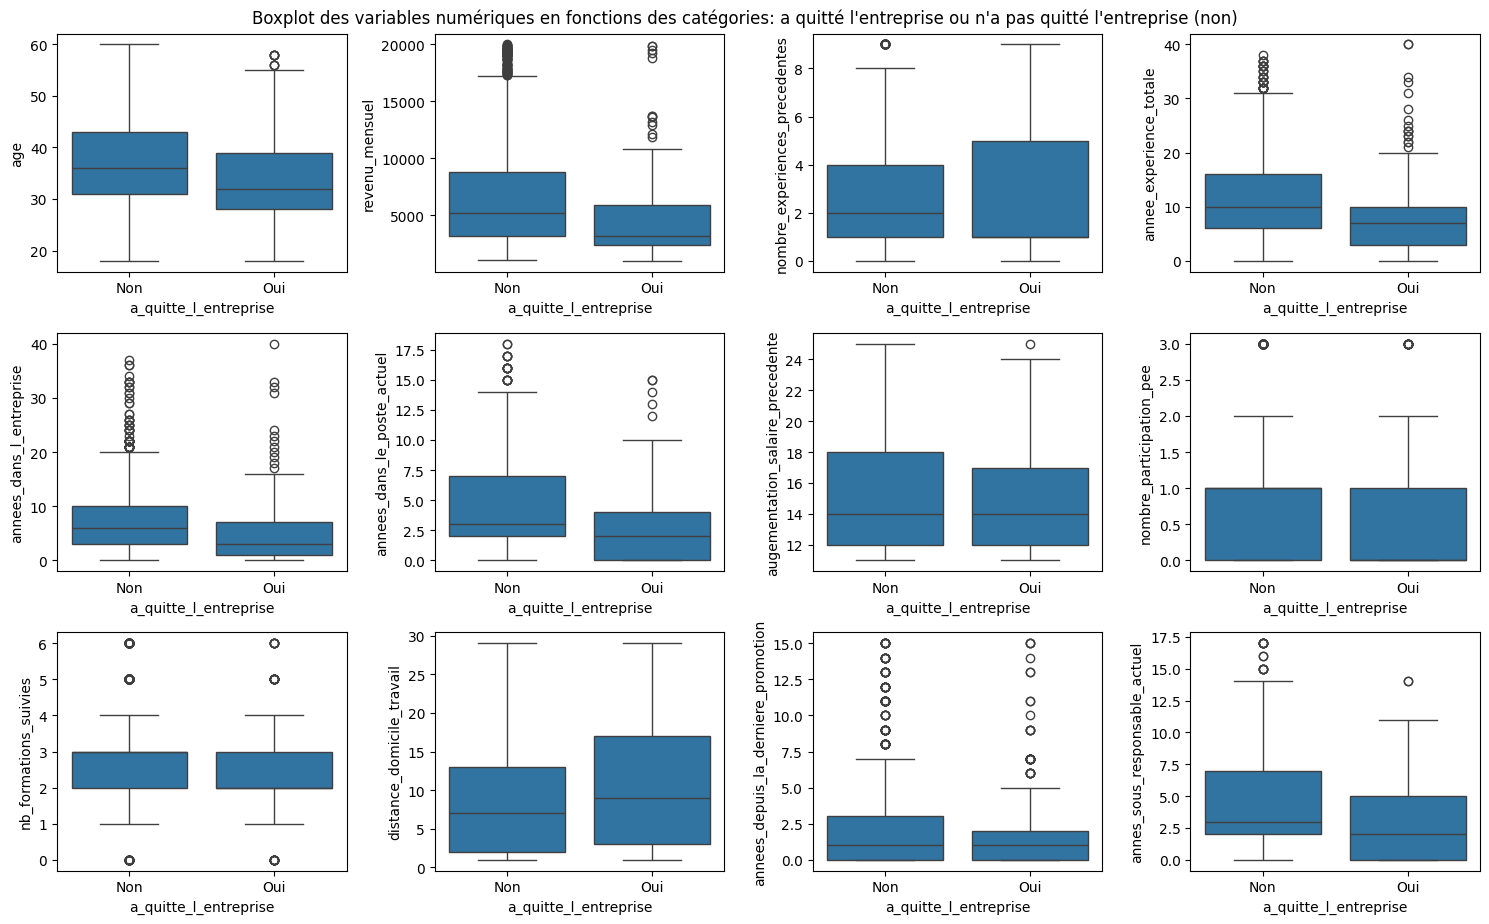

In [34]:
plt.figure(figsize = (15,12))
for i, col in enumerate(Variables_Numériques,1):
    plt.subplot(4,4,i)
    sns.boxplot(x = "a_quitte_l_entreprise", y = col, data = Data)

plt.suptitle("Boxplot des variables numériques en fonctions des catégories: a quitté l'entreprise ou n'a pas quitté l'entreprise (non)")
plt.tight_layout()
plt.show()

- **age :** Les personnes qui partent semblent plus jeunes.
- **revenu_mensuel :** Forte différence entre les deux groupes, les personnes qui partent semblent avoir un salaire moins important.
- **nombre-experience_precedente :** On ne note pas d'importantes différences entre les deux groupes.
- **annee_experience_totale :** Les personnes qui partent ont globalement moins d'années d'experiences.
- **annees_dans_l_entreprise :** les personnes qui partent sont globalement celles qui ont le moins d'années d'anciennenté.
- **annees_dans_le_poste_actuel :** même constat que pour la variable précédente.
- **augmentation_salaire_precedente :** On ne note pas d'importantes differences entre les deux groupes.
- **nombre_participation_pee :** les deux groupes semblent presque iddentiques.
- **nb_formations_suivies :** les deux groupes semblent presque iddentiques.
- **distance_domicile_travail :** les personnes qui partent semblent globalement habiter plus loin.
- **annees_depuis_la_derniere_promotion :** On ne note pas de différences flagrantes entre ces deux groupes.
- **annes_sous_responsable_actuel :** Les personnes qui partes sont généralement reesté moins longtemps sous le même responsable.

De ce qui précède les variables qui semblent pouvoir le plus influencer le modèle sont:
- age
- revenu_mensuel
- annee_experience_totale
- annees_dans_l_entreprise
- annees_dans_le_poste_actuel
- distance_domicile_travail
- annes_sous_responsable_actuel


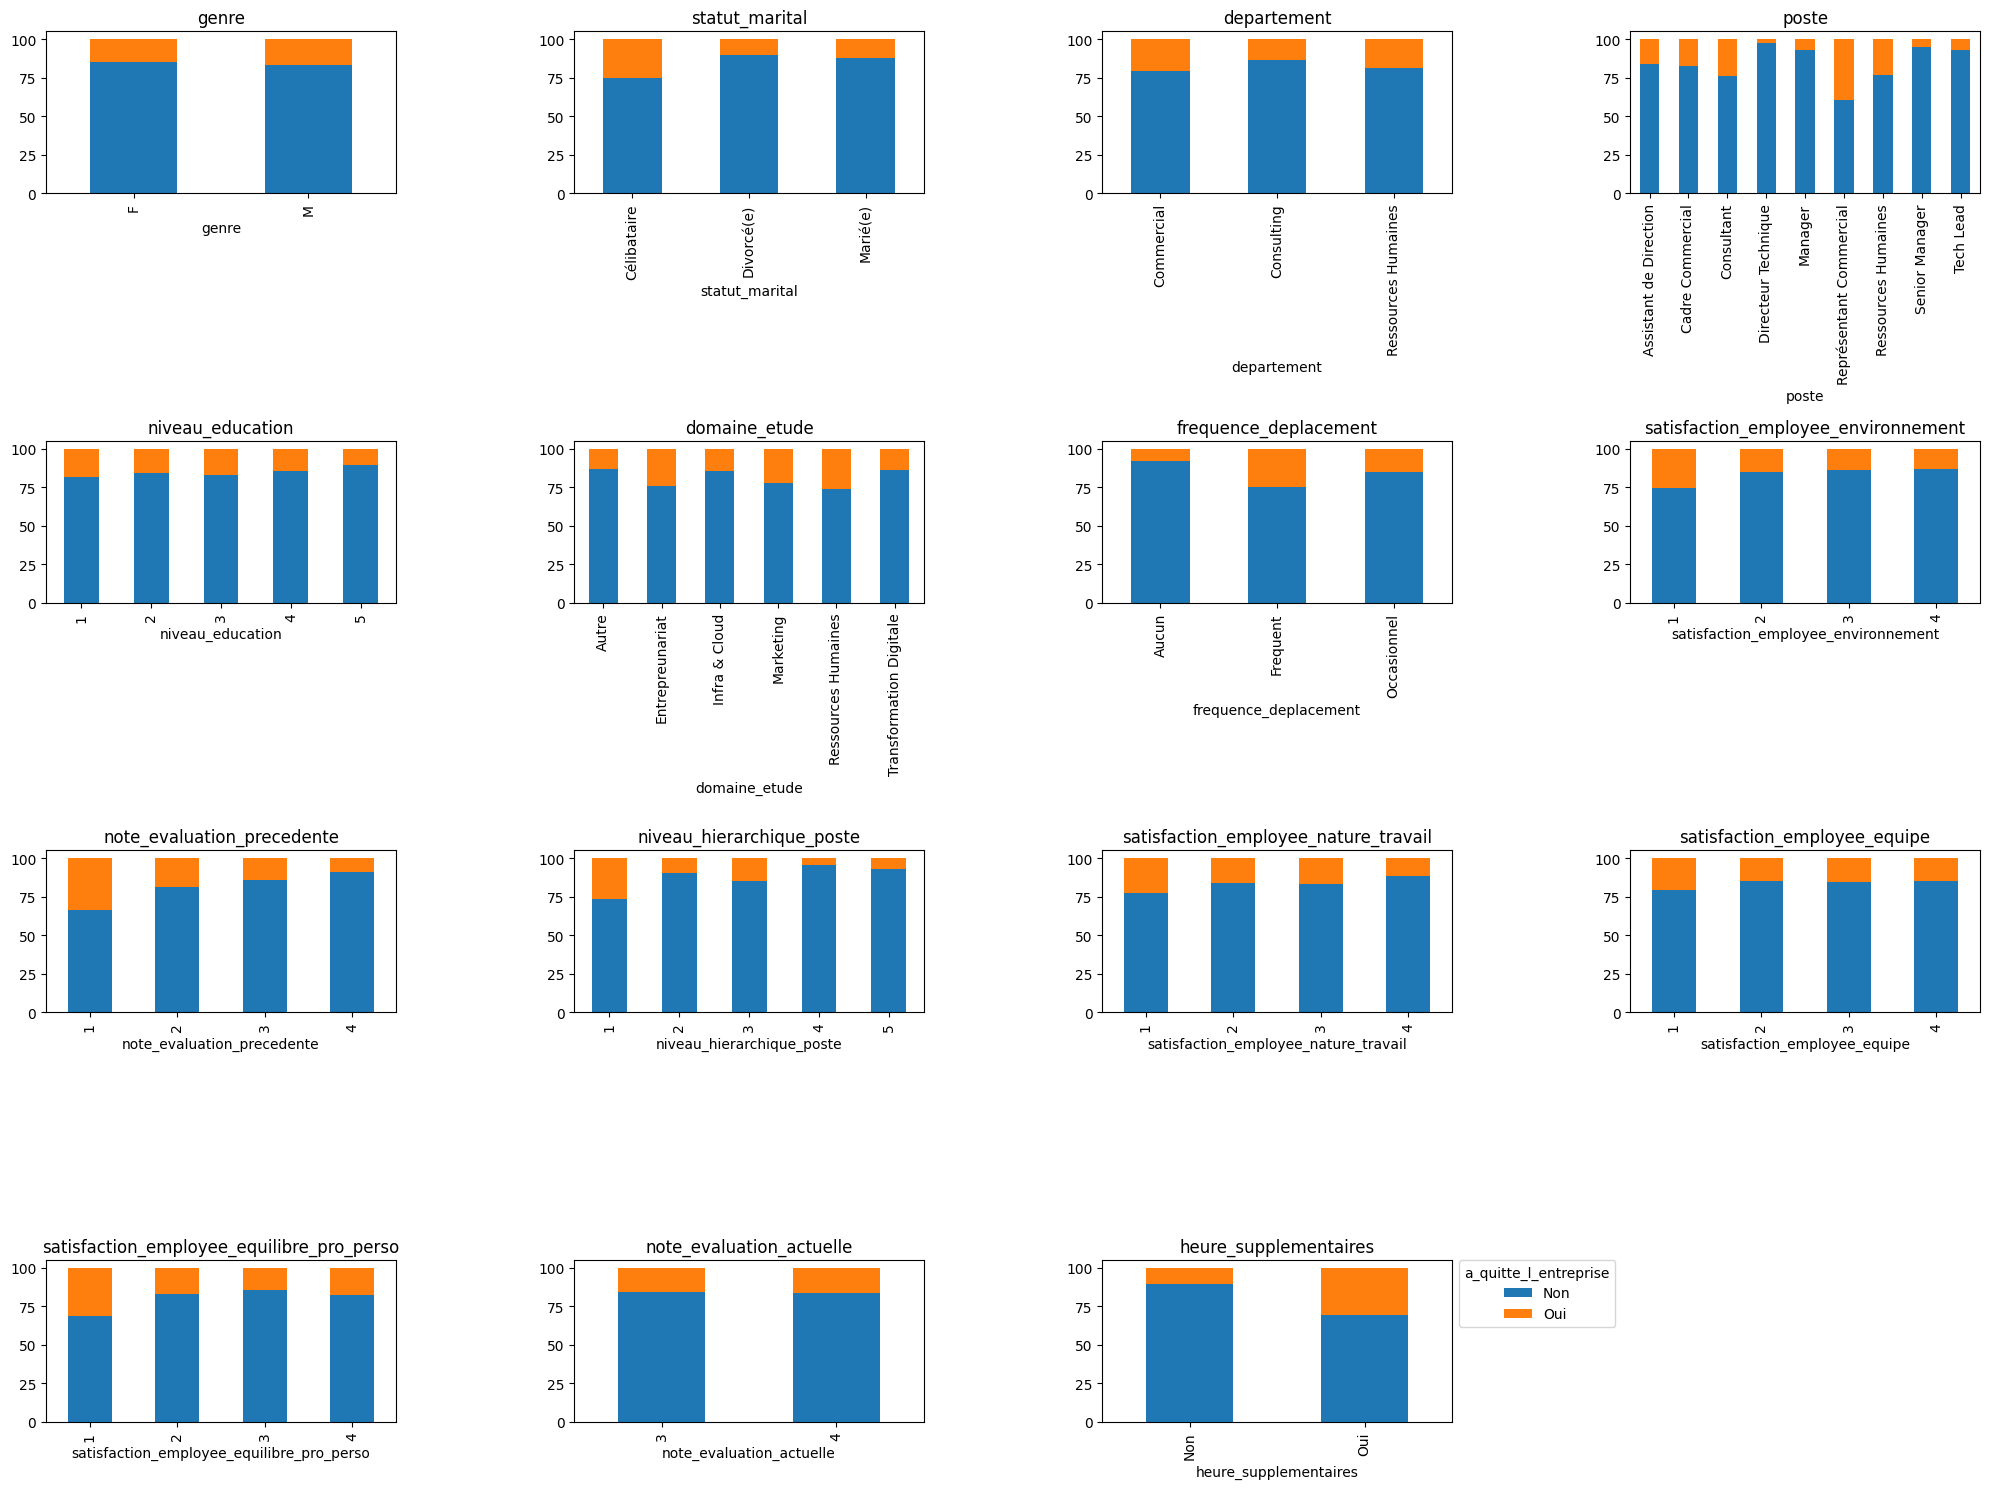

In [37]:
fig = plt.figure(figsize=(20,15))

Variables_categorielles_sans_cible = Variables_categorielles
Variables_categorielles_sans_cible.remove("a_quitte_l_entreprise")

for i, col in enumerate(Variables_categorielles, 1):
    if col != "a_quitte_l_entreprise":

        ax = plt.subplot(4,4,i)
        df = pd.crosstab(Data[col],Data["a_quitte_l_entreprise"],normalize="index") * 100
        df.plot(kind="bar", stacked=True, ax=ax, title=col)

        if ax.get_legend() is not None:
            ax.get_legend().remove()


handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, title="a_quitte_l_entreprise",loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

plt.tight_layout()
plt.show()

**Variables qui semblent avoir peu d'impact sur l'attrition :** 
- Le genre
- Le département
- note_evaluation_actuelle
- niveau_education



**Variables qui semblent avoir un impact sur l'attrition :**
- Le statut marital
- le poste
- L'ensemble des variable traduisant la satisfaction de l'employé
- note_evaluation_precedente
- niveau_hierarchique_poste
- heure_supplémentaires
- domaine d'étude
- fresuence_deplacement

Observons la répartition de notre variable cible:

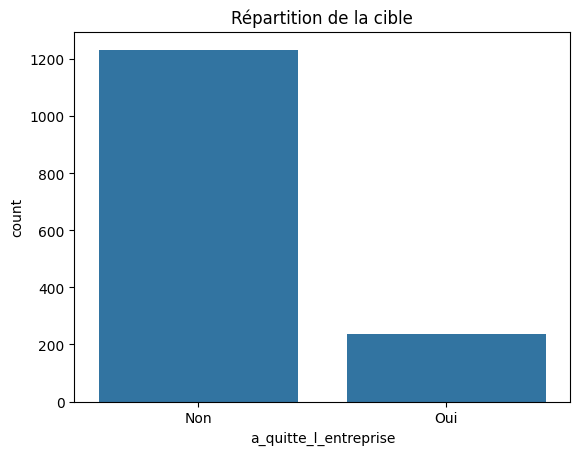

In [38]:
sns.countplot(x = "a_quitte_l_entreprise", data = Data)
plt.title("Répartition de la cible")
plt.show()

La répartition de la variable cible est déséquilibrée. on a une part bien plus importante de personnes qui restent que de personnes qui partent.

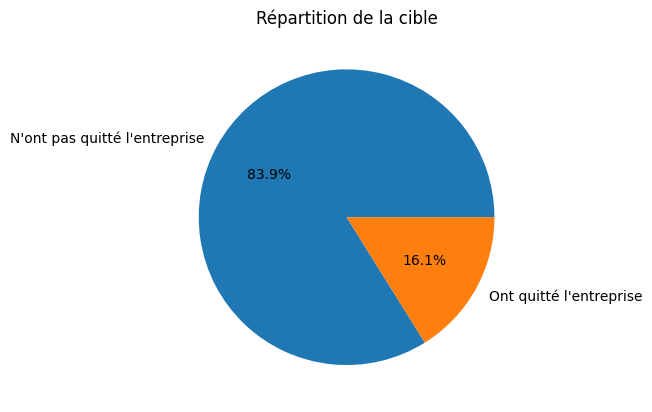

In [40]:
Data["a_quitte_l_entreprise"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["N'ont pas quitté l'entreprise", "Ont quitté l'entreprise"]
)

plt.ylabel("")
plt.title("Répartition de la cible")
plt.show()

## préparation des données pour la modélisation

On a iddentifé la variable cible comme étant a_quitte_l_entreprise. on peut donc séparer notre Dataframe en deux parties (Cible et features):

In [41]:
y = Data["a_quitte_l_entreprise"] # cible
X = Data.loc[:, Data.columns != "a_quitte_l_entreprise"] # features

In [42]:
X.shape

(1470, 27)

Regardons la matrice de correlation de Pearson:

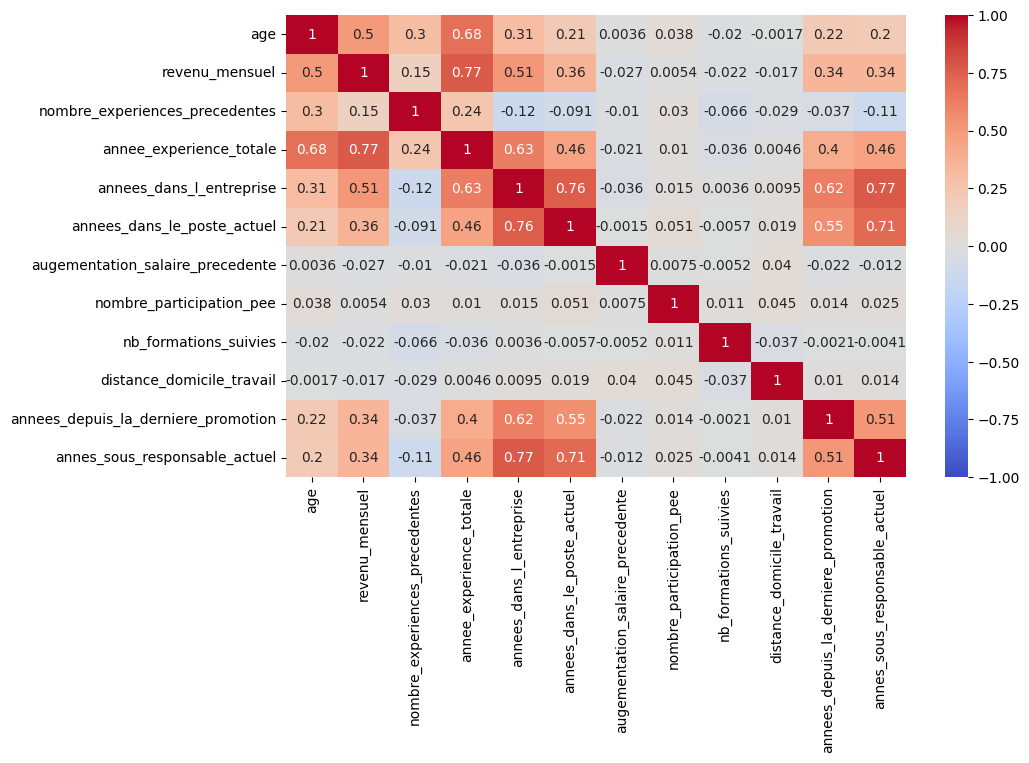

In [43]:
plt.figure(figsize=(10, 6))
correlation_Pearson = X[Variables_Numériques].corr(method="pearson")
sns.heatmap(correlation_Pearson, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

Les variables numériques ne semblent pas avoir de relations linéaires entre elles.

In [44]:
X = pd.get_dummies(X, columns = Variables_Nominatives, drop_first = True, dtype = int)
pd.set_option("display.max_columns", None)
X.head()

,age,revenu_mensuel,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,niveau_education,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,genre_M,statut_marital_Divorcé(e),statut_marital_Marié(e),departement_Consulting,departement_Ressources Humaines,poste_Cadre Commercial,poste_Consultant,poste_Directeur Technique,poste_Manager,poste_Représentant Commercial,poste_Ressources Humaines,poste_Senior Manager,poste_Tech Lead,domaine_etude_Entrepreunariat,domaine_etude_Infra & Cloud,domaine_etude_Marketing,domaine_etude_Ressources Humaines,domaine_etude_Transformation Digitale
0,41,5993,8,8,6,4,0,0,1,2,Occasionnel,0,5,2,3,2,4,1,1,3,Oui,11,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
1,49,5130,1,10,10,7,1,3,8,1,Frequent,1,7,3,2,2,2,4,3,4,Non,23,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,37,2090,6,7,0,0,0,3,2,2,Occasionnel,0,0,4,2,1,3,2,3,3,Oui,15,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,33,2909,1,8,8,7,0,3,3,4,Frequent,3,0,4,3,1,3,3,3,3,Oui,11,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,27,3468,9,6,2,2,1,3,2,1,Occasionnel,2,2,1,3,1,2,4,3,3,Non,12,1,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1


In [45]:
encoder = OrdinalEncoder(categories = [["Aucun", "Occasionnel", "Frequent"]])
X["frequence_deplacement"] = encoder.fit_transform(X[["frequence_deplacement"]])
X.head()

,age,revenu_mensuel,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,niveau_education,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,genre_M,statut_marital_Divorcé(e),statut_marital_Marié(e),departement_Consulting,departement_Ressources Humaines,poste_Cadre Commercial,poste_Consultant,poste_Directeur Technique,poste_Manager,poste_Représentant Commercial,poste_Ressources Humaines,poste_Senior Manager,poste_Tech Lead,domaine_etude_Entrepreunariat,domaine_etude_Infra & Cloud,domaine_etude_Marketing,domaine_etude_Ressources Humaines,domaine_etude_Transformation Digitale
0,41,5993,8,8,6,4,0,0,1,2,1.0,0,5,2,3,2,4,1,1,3,Oui,11,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
1,49,5130,1,10,10,7,1,3,8,1,2.0,1,7,3,2,2,2,4,3,4,Non,23,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,37,2090,6,7,0,0,0,3,2,2,1.0,0,0,4,2,1,3,2,3,3,Oui,15,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,33,2909,1,8,8,7,0,3,3,4,2.0,3,0,4,3,1,3,3,3,3,Oui,11,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,27,3468,9,6,2,2,1,3,2,1,1.0,2,2,1,3,1,2,4,3,3,Non,12,1,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1


In [46]:
X["heure_supplementaires"] = X["heure_supplementaires"].map({"Non":0, "Oui":1})
X.head()

,age,revenu_mensuel,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,niveau_education,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,genre_M,statut_marital_Divorcé(e),statut_marital_Marié(e),departement_Consulting,departement_Ressources Humaines,poste_Cadre Commercial,poste_Consultant,poste_Directeur Technique,poste_Manager,poste_Représentant Commercial,poste_Ressources Humaines,poste_Senior Manager,poste_Tech Lead,domaine_etude_Entrepreunariat,domaine_etude_Infra & Cloud,domaine_etude_Marketing,domaine_etude_Ressources Humaines,domaine_etude_Transformation Digitale
0,41,5993,8,8,6,4,0,0,1,2,1.0,0,5,2,3,2,4,1,1,3,1,11,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
1,49,5130,1,10,10,7,1,3,8,1,2.0,1,7,3,2,2,2,4,3,4,0,23,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,37,2090,6,7,0,0,0,3,2,2,1.0,0,0,4,2,1,3,2,3,3,1,15,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,33,2909,1,8,8,7,0,3,3,4,2.0,3,0,4,3,1,3,3,3,3,1,11,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,27,3468,9,6,2,2,1,3,2,1,1.0,2,2,1,3,1,2,4,3,3,0,12,1,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1


In [47]:
X["temps sans promotion"] = X["annees_dans_l_entreprise"] - X["annees_dans_le_poste_actuel"]

In [48]:
X["Valorisation experience"] = X["revenu_mensuel"]/X["annee_experience_totale"]
X["Valorisation experience"] = X["Valorisation experience"].replace(np.inf, 0) # On remplace les infinis par 0 (Pas d'experience)

In [49]:
X["Valorisation interne"] = X["revenu_mensuel"]/X["annees_dans_l_entreprise"]
X["Valorisation interne"] = X["Valorisation interne"].replace(np.inf, 0) # On remplace les infinis par 0 (nouvel element dans l'entreprise)

In [50]:
X["part de carrière dans l'entreprise"] = X["annees_dans_l_entreprise"]/X["annee_experience_totale"]
X["part de carrière dans l'entreprise"] = X["part de carrière dans l'entreprise"].fillna(0) #certains n'ont pas d'experience totale, donc pas d'experience dans l'entreprise non plus (0/0)

In [51]:
y = y.map({"Non":0, "Oui":1})
y

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: a_quitte_l_entreprise, Length: 1470, dtype: category
Categories (2, int64): [0, 1]

In [52]:
X.shape

(1470, 44)

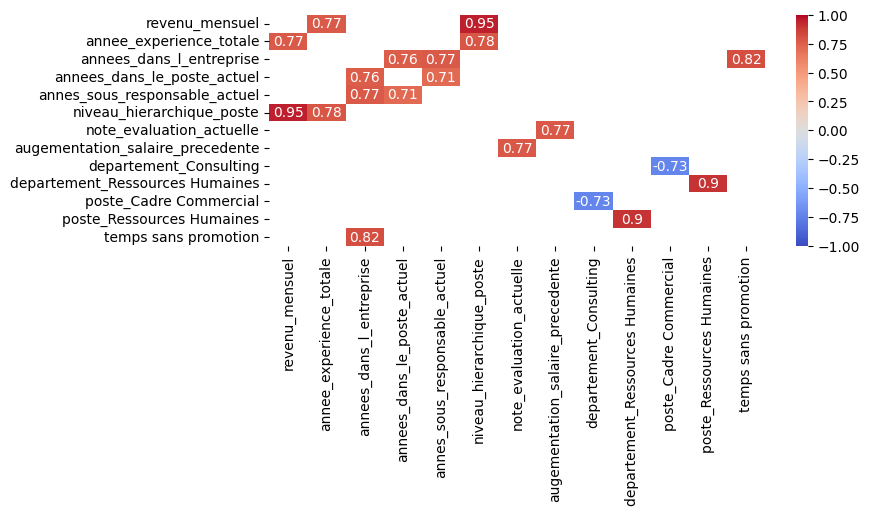

In [53]:
plt.figure(figsize=(8,3))
correlation_Pearson = X.corr(method="pearson")
filtered_correlation = correlation_Pearson.where((abs(correlation_Pearson) > 0.7) & (abs(correlation_Pearson) < 1))
filtered_correlation = filtered_correlation.dropna(axis=0, how='all')
filtered_correlation = filtered_correlation.dropna(axis=1, how='all')
sns.heatmap(filtered_correlation, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

On concervera les variables poste_ressource_Humaines, et departement ressources humaines, car elles ne cpatent pas la même information.  
En revanche on a une forte correlation entre revenu_mensuel, et niveau_hierarchique_poste, on ne concervara que le revenu mensuel.

In [54]:
X.drop("niveau_hierarchique_poste", axis = 1, inplace = True)

In [55]:
X.drop("departement_Ressources Humaines", axis = 1, inplace = True)

In [56]:
corr_pairs = correlation_Pearson.unstack()

strong_corr = corr_pairs[(abs(corr_pairs) > 0.7) & (abs(corr_pairs) < 1)]

print(strong_corr.sort_values(ascending=False))

revenu_mensuel                    niveau_hierarchique_poste           0.950300
niveau_hierarchique_poste         revenu_mensuel                      0.950300
poste_Ressources Humaines         departement_Ressources Humaines     0.904983
departement_Ressources Humaines   poste_Ressources Humaines           0.904983
temps sans promotion              annees_dans_l_entreprise            0.819709
annees_dans_l_entreprise          temps sans promotion                0.819709
annee_experience_totale           niveau_hierarchique_poste           0.782208
niveau_hierarchique_poste         annee_experience_totale             0.782208
augementation_salaire_precedente  note_evaluation_actuelle            0.773550
note_evaluation_actuelle          augementation_salaire_precedente    0.773550
revenu_mensuel                    annee_experience_totale             0.772893
annee_experience_totale           revenu_mensuel                      0.772893
annes_sous_responsable_actuel     annees_dans_l_entr

In [57]:
X.shape

(1470, 42)

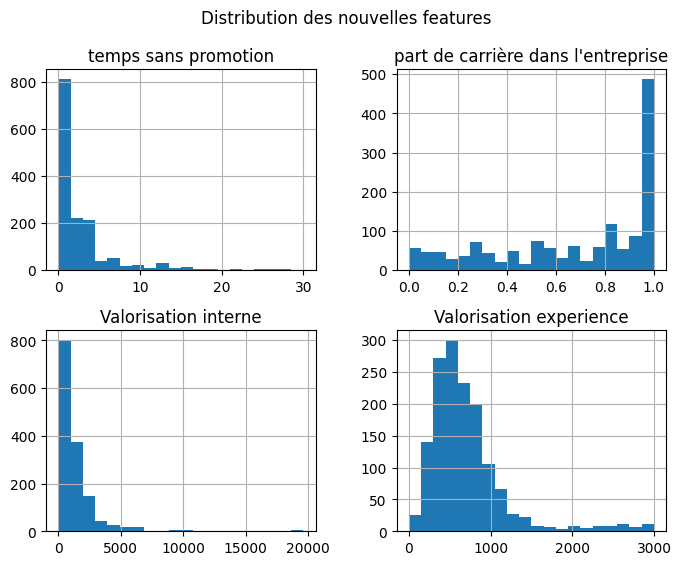

In [58]:
X[["temps sans promotion","part de carrière dans l'entreprise","Valorisation interne", "Valorisation experience"]].hist(figsize = (8,6), bins = 20)
plt.suptitle("Distribution des nouvelles features")
plt.show()

- **temps sans promotion :** Répartition de la variable asymétrique à droite, beaucoup d'employés à 0 (lié au fait qu'i y ait beaucoup de nouveaux employés).
- **valorisation interne :** Répartition de la variable asymétrique à droite, quelques très grandes valeurs à 20000.
- **part de carrière dans l'entreprise :** Répartition de la variable asymétrique à gauche. beaucoup d'employés ont fait la totalité de leur carrière au sein de cette entreprise.
- **Valorisation experience :** Répartition de la variable asymétrique à droite, quelques grandes valeurs à 3000.

In [59]:
X.describe()

,age,revenu_mensuel,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,augementation_salaire_precedente,genre_M,statut_marital_Divorcé(e),statut_marital_Marié(e),departement_Consulting,poste_Cadre Commercial,poste_Consultant,poste_Directeur Technique,poste_Manager,poste_Représentant Commercial,poste_Ressources Humaines,poste_Senior Manager,poste_Tech Lead,domaine_etude_Entrepreunariat,domaine_etude_Infra & Cloud,domaine_etude_Marketing,domaine_etude_Ressources Humaines,domaine_etude_Transformation Digitale,temps sans promotion,Valorisation experience,Valorisation interne,part de carrière dans l'entreprise
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,6502.931293,2.693197,11.279592,7.008163,4.229252,0.793878,2.799320,9.192517,1.086395,2.187755,4.123129,15.209524,0.600000,0.222449,0.457823,0.653741,0.221769,0.176190,0.054422,0.089116,0.056463,0.035374,0.069388,0.098639,0.089796,0.412245,0.108163,0.018367,0.315646,2.778912,706.864953,1505.816347,0.678074
std,9.135373,4707.956783,2.498009,7.780782,6.126525,3.623137,0.852077,1.289271,8.106864,0.532170,3.222430,3.568136,3.659938,0.490065,0.416033,0.498387,0.475939,0.415578,0.381112,0.226925,0.285008,0.230891,0.184786,0.254199,0.298279,0.285986,0.492406,0.310692,0.134321,0.464931,4.120310,483.627811,2097.996088,0.328093
min,18.000000,1009.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,2911.000000,1.000000,6.000000,3.000000,2.000000,0.000000,2.000000,2.000000,1.000000,0.000000,2.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,409.303571,563.513587,0.411765
50%,36.000000,4919.000000,2.000000,10.000000,5.000000,3.000000,1.000000,3.000000,7.000000,1.000000,1.000000,3.000000,14.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,597.783333,903.225000,0.800000
75%,43.000000,8379.000000,4.000000,15.000000,9.000000,7.000000,1.000000,3.000000,14.000000,1.000000,3.000000,7.000000,18.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,3.000000,840.906250,1514.791667,1.000000
max,60.000000,19999.000000,9.000000,40.000000,40.000000,18.000000,3.000000,6.000000,29.000000,2.000000,15.000000,17.000000,25.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,30.000000,2994.000000,19613.000000,1.000000


## Modélisation

Nous allons tester plusieurs modèles de classification dans le but de tanter de prédir quels sont les employés qui ont de fortes chances de quitter l'entreprise.  
A cet effet nous allons comparer plusieurs modèles selon différentes métriques.  
Notons qu'il est plus grave de ne pas prédir le départ d'un employé, que de prédir faussement le départ d'un employé. Nous préviligierons donc la métrique "recall", qui maximise le nombre de vrai positifs détéctés (le nombre de vrais départ détécté dans notre cas).

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Variables_a_standardiser = Variables_Numériques.copy()
Variables_a_standardiser.remove("revenu_mensuel") # on distinge les variables ou on utilisera log et standardisation, des variables ou on utilisera simplement la standardisation
Variables_a_standardiser.extend(["temps sans promotion","part de carrière dans l'entreprise" ])
Variables_log = ["revenu_mensuel", "Valorisation experience", "Valorisation interne"]
Variables_categorielles = [ col for col in X.columns if col not in Variables_log + Variables_a_standardiser]

log_pipeline = Pipeline([("log", FunctionTransformer(np.log1p)), ("scaler", StandardScaler())])
numeric_pipeline = Pipeline([("scaler", StandardScaler())])

preprocessor = ColumnTransformer([("log_num", log_pipeline, Variables_log), ("num", numeric_pipeline, Variables_a_standardiser), ("cat", "passthrough", Variables_categorielles)])

models = {"Dummy": DummyClassifier(strategy = "stratified"),
          "LogisticRegression": LogisticRegression(class_weight = "balanced", max_iter = 1000),
          "RandomForest": RandomForestClassifier( class_weight = "balanced", random_state = 42),
          "XGBoost": XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=42, n_jobs=-1)}

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42) #validation croisée stratifiée

results = []

for name, model in models.items():
    pipeline = Pipeline([("preprocessing", preprocessor), ("model", model)])
    scores = cross_validate(pipeline, X_train, y_train, cv = cv, scoring = ["accuracy", "precision", "recall", "f1", "average_precision"], n_jobs = -1)
    results.append({"model": name,
                    "accuracy_moyenne": scores["test_accuracy"].mean(),
                    "accuracy_ecart_type": scores["test_accuracy"].std(),
                    "precision_moyenne": scores["test_precision"].mean(),
                    "precision_ecart_type": scores["test_precision"].std(),
                    "recall_moyenne": scores["test_recall"].mean(),
                    "recall_ecart_type": scores["test_recall"].std(),
                    "f1_moyenne": scores["test_f1"].mean(),
                    "f1_ecart_type": scores["test_f1"].std(),
                    "pr_auc_moyenne": scores["test_average_precision"].mean(),
                    "pr_auc_ecart_type": scores["test_average_precision"].std()})

resultats = pd.DataFrame(results)
resultats = resultats.sort_values("recall_moyenne", ascending=False).round(3)
resultats

,model,accuracy_moyenne,accuracy_ecart_type,precision_moyenne,precision_ecart_type,recall_moyenne,recall_ecart_type,f1_moyenne,f1_ecart_type,pr_auc_moyenne,pr_auc_ecart_type
1,LogisticRegression,0.759,0.026,0.378,0.027,0.732,0.079,0.496,0.015,0.632,0.071
3,XGBoost,0.865,0.009,0.680,0.066,0.326,0.074,0.433,0.071,0.565,0.071
2,RandomForest,0.856,0.008,0.858,0.143,0.147,0.059,0.243,0.086,0.523,0.058
0,Dummy,0.714,0.026,0.118,0.057,0.116,0.052,0.117,0.054,0.174,0.019


l'accuracy (exactitude), est trompeuse car nous avanon vu précédemment que les deux populations de la variable cible étaient déséquilibrée.
La régression losgistique semble être le meilleur modèle: recall le plus important (vrais départs détéctés) 0,732, en revanche sa precision est plutot faible (proportion de vrais départs parmis les départs predit).  
On peut utiliser SMOTE pour tanter de régler le problème de déséquilibre.  
On concervera également le mailleur modèle non linéaire parmis ceux que nous avons testé, afin de comparer nos deux meilleurs modèles dans la suite.  
Le meilleur modèle non linéaire est donc le modèle XGBoost, avec un recall de 0,326, nettement moins bon que que le modèle logistique.

testons à nouveau nos modèles cette fois en utilisant le module SMOTE afin de mieux gérer le déséquilibre entre les deux catégories de la variable cible (départ ou non).  
**Principe:** créer des observations artificielles (s'inspirant du jeu de données) de la classe minoritaire pour aumenter le nombre d'observations dans cette dernière.

In [61]:
# 1. Définition des modèles.
models = {"LogisticRegression": LogisticRegression(class_weight="balanced", max_iter=1000),
          "RandomForest": RandomForestClassifier(class_weight="balanced", random_state=42),
          "XGBoost": XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=42, n_jobs=-1),
          "Dummy": DummyClassifier(strategy="stratified")}

# 2. création d'une liste vide permettant de stocker nos résultats
results_smote = []

# 3. Boucle sur les modèles avec creation d'un pipeline contenant le module smote.
for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "average_precision"],
        n_jobs=-1
    )

    results_smote.append({
        "model": name + " + SMOTE",

        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),

        "precision_mean": scores["test_precision"].mean(),
        "precision_std": scores["test_precision"].std(),

        "recall_mean": scores["test_recall"].mean(),
        "recall_std": scores["test_recall"].std(),

        "f1_mean": scores["test_f1"].mean(),
        "f1_std": scores["test_f1"].std(),

        "pr_auc_moyenne": scores["test_average_precision"].mean(),
        "pr_auc_std": scores["test_average_precision"].std()})

# 4. Tableau final
resultats_smote = pd.DataFrame(results_smote)
resultats_smote = resultats_smote.sort_values("f1_mean", ascending=False).round(3)

resultats_smote

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,pr_auc_moyenne,pr_auc_std
0,LogisticRegression + SMOTE,0.772,0.028,0.392,0.039,0.711,0.076,0.502,0.035,0.627,0.066
2,XGBoost + SMOTE,0.864,0.011,0.654,0.077,0.358,0.059,0.457,0.047,0.583,0.059
1,RandomForest + SMOTE,0.870,0.012,0.760,0.106,0.295,0.077,0.417,0.083,0.564,0.078
3,Dummy + SMOTE,0.542,0.016,0.182,0.008,0.526,0.024,0.271,0.010,0.162,0.011


Le meilleur modèle demeure la regression logistique avec un recall de 0,711, qui est donc légèrement infèrieur que précédament.  
EN revanche le meilleur modèle non linéaire est le XGBoost avec un recall de 0,358, qui est légerement meilleur que précédament.  
On notte également une améliration de la précision (donc moins de faux départs prédits poure la regression logistique), et une légère baisse pour XGBoost.  
L'aire sous la courbe PR a légèrement diminué pour la regression logistique et légèrement augmenté pour le XGBoost.  
On en déduit que le module SMOTE n'améliore pas nos modèles, on ne l'utilisera donc pas dans la suite.

Observons plus en détail nos deux modèles.

In [62]:
# On selectionne notre modèle logistique.
best_model = Pipeline([("preprocessing", preprocessor),("model", models["LogisticRegression"])])
best_model.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_num', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting

In [63]:
# On selectionne notre modèle XGBoost.
Second_best_model = Pipeline([("preprocessing", preprocessor),("model", models["XGBoost"])])
Second_best_model.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_num', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting

In [64]:
# On récupère les prédictions et les probabilités de départs (classe 1) de nos deux modèles
y_pred_logistique = best_model.predict(X_test)
y_proba_logistique = best_model.predict_proba(X_test)[:, 1]
y_pred_XGBoost = Second_best_model.predict(X_test)
y_proba_XGBoost = Second_best_model.predict_proba(X_test)[:, 1]

### Matrices de confusions

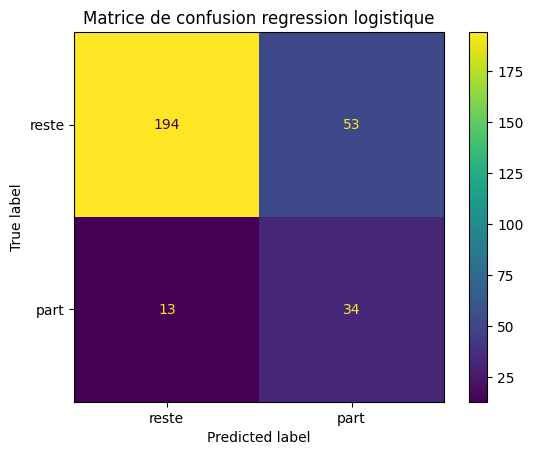

In [65]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test,  display_labels=["reste", "part"])
plt.title("Matrice de confusion regression logistique")
plt.show()

Le modèle logistique prédit 34 vrais départs, mais en manque 13.  
il prédit également 53 faux départs. 

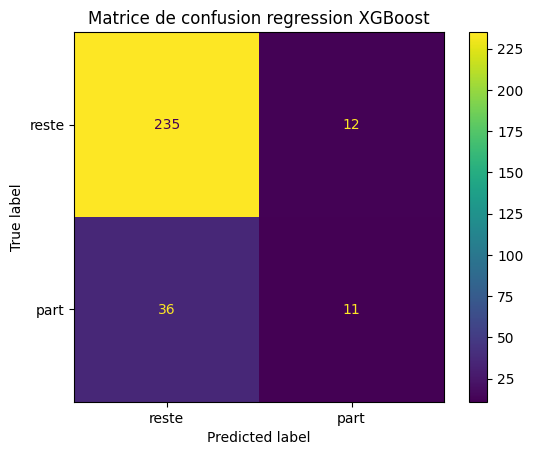

In [66]:
ConfusionMatrixDisplay.from_estimator(Second_best_model, X_test, y_test,  display_labels=["reste", "part"])
plt.title("Matrice de confusion regression XGBoost")
plt.show()

Le modèle XGBoost prédit 11 vrais départs, mais en manque 36.  
En revanche il ne prédit que 12 faux départs.

Le modèle XGBoost est donc plus précis que le modèle logistique, mais comme nous l'avons dit précédemment, dans notre situation le rappel est plus important que la précision, et le modèle XGBoost manque beaucoup plus de départs que le modèle logistique.  
Dans notre contexte, le modèle logistique semble donc meilleur que le modèle XGBoost.

### Courbe précision rappel

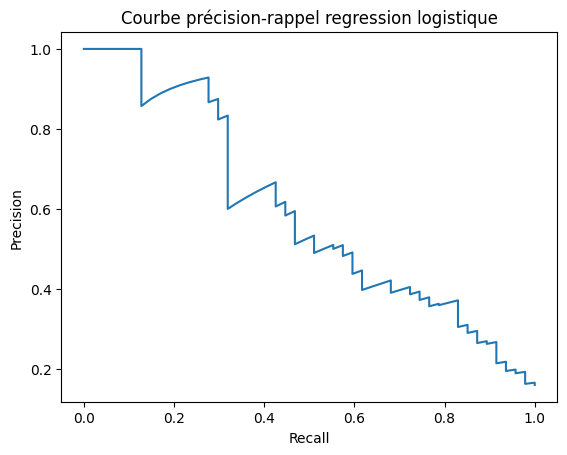

In [67]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_logistique)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe précision-rappel regression logistique")
plt.show()

La courbe précision-rappel du modèle de regression logistique montre que plus le rappel augmente plus la precision diminue. Donc le modèle semble parvenir à identifier une partie des observations positives, mais au prix d’un nombre important de faux positifs.

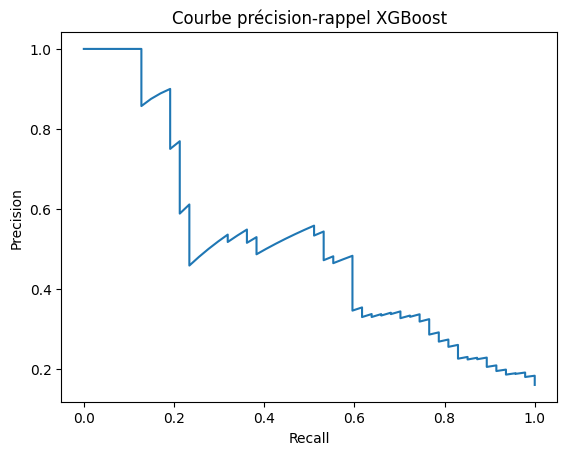

In [68]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_XGBoost)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe précision-rappel XGBoost")
plt.show()

La courbe du modèle XGBoost semble un peu moins bonne que celle du modèle de régression logistique.  
La précicion chute rapidement, et semble relativement instable pour un recall compris entre 0.2, et 0.6, passé cette valeur, la précision est relativement faible (entre 0.2, et 0.3)

### Evaluation des performances des modèles

In [69]:
# Pour la régression logistique.

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_recall = recall_score(y_train, y_train_pred)
test_recall = recall_score(y_test, y_test_pred)

pd.DataFrame({"Dataset": ["Train", "Test"],
              "Recall": [round(train_recall, 3), round(test_recall, 3)]})

,Dataset,Recall
0,Train,0.811
1,Test,0.723


Pour le modele de regression logistique, le recall sur le test est un peu plus bas que sur le train, donc le modèle apprend bien les patterns du train et généralise correctement sur le test.On observe un très léger surapprentissage, donc une lègère perte de performance sur le test.

In [70]:
# Pour XGBoost

y_train_pred = Second_best_model.predict(X_train)
y_test_pred = Second_best_model.predict(X_test)

train_recall = recall_score(y_train, y_train_pred)
test_recall = recall_score(y_test, y_test_pred)

pd.DataFrame({"Dataset": ["Train", "Test"],
              "Recall": [round(train_recall, 3), round(test_recall, 3)]})

,Dataset,Recall
0,Train,1.000
1,Test,0.234


Pour le modèle XGBoost, le recall du test est beaucoup plus bas que celui du train, donc le modèle surapprend.  
On essaira de regler ce problème en reglant les hyperparamètres de ce modèle dans la partie suivante.

## optimisation

### modèle logistique

In [71]:
# Pipeline complet
pipeline = Pipeline([("preprocessing", preprocessor),("model", LogisticRegression(max_iter=5000,class_weight="balanced"))]) # On augmente le nombre d'itérations

# Grille hyperparamètres (sans penalty)
param_grid = {"model__solver": ["lbfgs", "liblinear", "saga"],
              "model__C": [0.01, 0.1, 1, 10, 100]}

# GridSearch
grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring="recall", n_jobs=-1, verbose=1)

grid.fit(X_train, y_train)

# Meilleur modèle
best_logreg = grid.best_estimator_

print("Best params :", grid.best_params_)
print("Best CV recall :", grid.best_score_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best params : {'model__C': 0.01, 'model__solver': 'lbfgs'}
Best CV recall : 0.7736842105263158


Le meilleur modèle pour la régression linéaire a pour hyperparamètres:  
- c = 0,01 (modèle simple qui eveite d'expliquer toute les variations, et donc évite le surapprentissage).
- solver = lbfgs (algorithme qui trouve les coefficients qui minimisent l'erreur du modèle).



Le modèle a un recall de 0,77.

### modèle XGBoost

In [72]:
# Pipeline
pipeline_xgb = Pipeline([("preprocessing", preprocessor),("model", XGBClassifier(objective="binary:logistic",eval_metric="logloss",random_state=42,n_jobs=-1, n_estimators=2000))])

# Grille hyperparamètres
param_grid_xgb = {"model__max_depth": [3, 4, 5, 6, 7],
                  "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
                  "model__subsample": [0.6, 0.8, 1],
                  "model__colsample_bytree": [0.6, 0.8, 1]}

# GridSearch
grid_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, cv=cv, scoring="recall", n_jobs=-1, verbose=1)

grid_xgb.fit(X_train, y_train)

# Meilleur modèle
best_xgb = grid_xgb.best_estimator_

print("Best params:", grid_xgb.best_params_)
print("Best CV recall:", grid_xgb.best_score_)

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__subsample': 0.8}
Best CV recall: 0.41052631578947374


Le meilleur modèle pour XGBoost:  
- colsample_bytree = 0,8 (Le modèle utilise 80% des variables)
- learning_rate = 0.1 (vitesse d'apprentissage)
- max_depth = 3 (profondeur maximale des arbres)
- subsample = 0,8 (Le modèle utilise 80% des données)




Le modèle a un recall de 0,41

On récupère les prédictions et les probabilités de départs (classe 1) de nos deux modèles optimisés.

In [73]:
# Logistic Regression
y_pred_log = best_logreg.predict(X_test)
y_proba_log = best_logreg.predict_proba(X_test)[:, 1]

# XGBoost
y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

### matrice de confusion

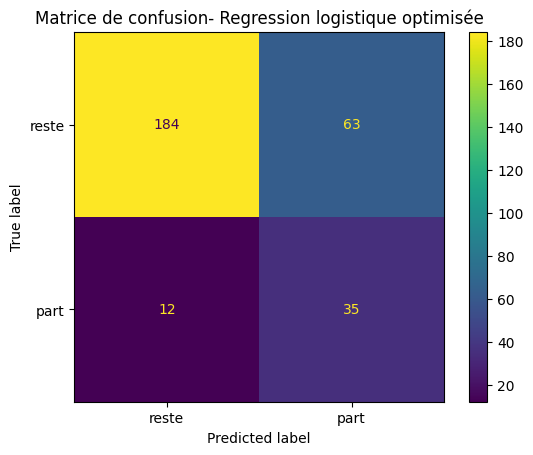

In [74]:
# Regression logistique
ConfusionMatrixDisplay.from_estimator(best_logreg, X_test, y_test, display_labels=["reste", "part"])
plt.title("Matrice de confusion- Regression logistique optimisée")
plt.show()

Le modèle de regression logistique optimisé, prédit 35 vrais départs, mais en laisse passer 12. ce qui confirme une légère augmentation du recall. En revanche on note également une légère baisse de la precision avec 63 faux départs signalés.

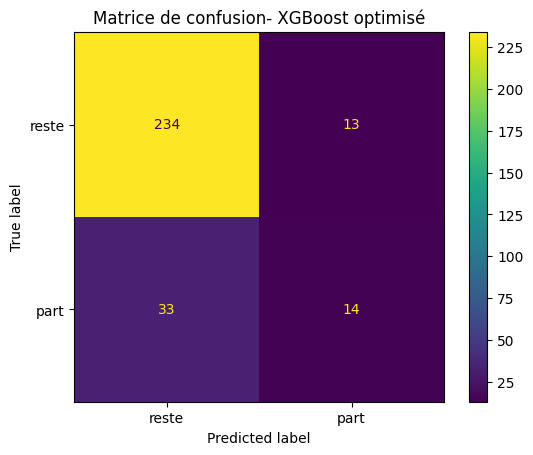

In [75]:
# XGBoost
ConfusionMatrixDisplay.from_estimator(best_xgb, X_test, y_test, display_labels=["reste", "part"])
plt.title("Matrice de confusion- XGBoost optimisé")
plt.show()

On observe une légère amèlioration du recall pour le modèle XGBoost, et une très légère baisse de la précision.

### courbe PR

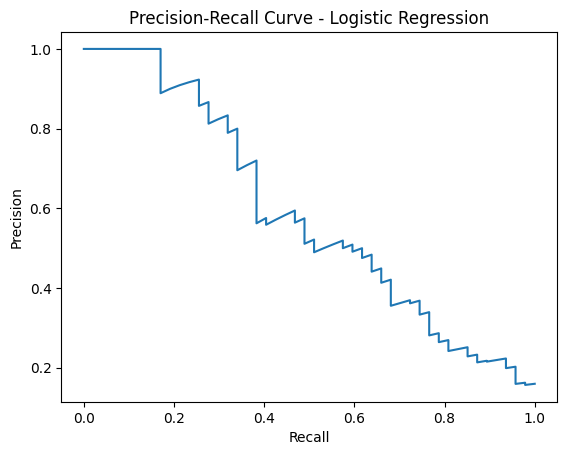

In [76]:
# Regression logistique
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_log)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.show()

L’optimisation des hyperparamètres via Grid Search n’a pas entraîné d’amélioration significative de la courbe précision-rappel pour le modèle logistique. Les performances du modèle optimisé restent proches de celles du modèle initial, avec un compromis précision/rappel similaire. A partir d'un recall de 0.8, la precision chute aux alentours de 0,25-0,3.  
On preférera privilégier le recall, car un départ non prévu a un cout plus élévé pour l'entreprise qu'un faux départ.
On a vu au début que le pourcentage de départ était de l'ordre de 16% (donc si on prend un employé au hasard il y a 16% de chances que ca soit un employer qui veuille partir).  
La zone la plus pertinente de la courbe précision-rappel se situe pour des valeurs de recall élevées (environ 0.7 à 0.85), car l’objectif est de détecter un maximum d’employés susceptibles de quitter l’entreprise.
Cette zone permet de conserver une précision encore acceptable tout en limitant les faux négatifs.  
On cherchera donc un modèle dont la precision soit significativement meilleure que le hasard soit au moins de 25%.

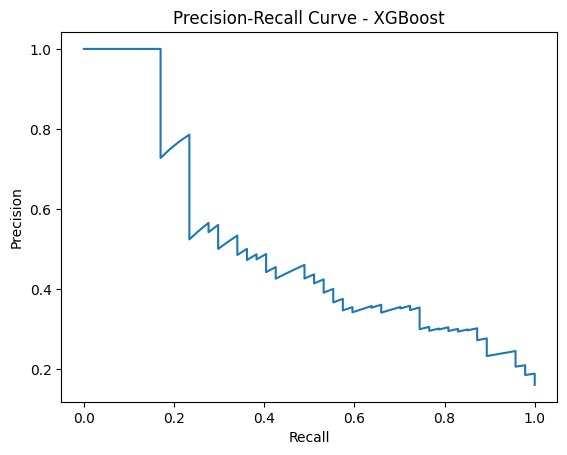

In [77]:
# XGBoost
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_xgb)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")
plt.show()

Le modèle est très precis pour un recall entre 0 et 0.2, puis la precision diminue rapidement.
La zone d'intéret se situe entre 0.7 et 0.8 pour le recall, ce qui correspond à une precision aux alentours de 0,3.

### Définition d'un nouveau seuil

#### **Regression ligistique**

Observons comment le modèle de regression logistique catégorise les emlpoyés en fonction des probabilités:

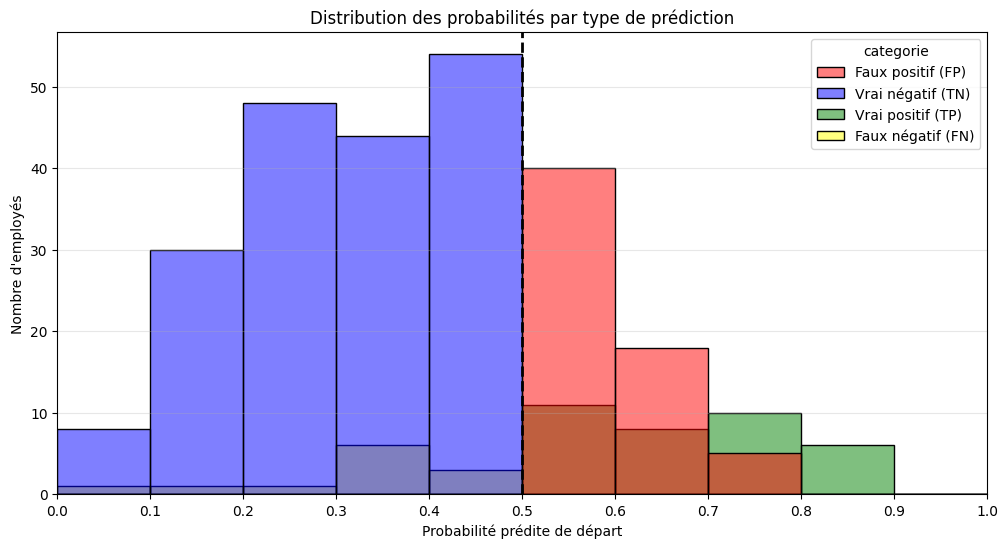

In [78]:
# seuil de classification
threshold = 0.5

# prédictions selon le seuil
y_pred_threshold = (y_proba_log >= threshold).astype(int)

# dataframe pour le graphique
df_plot = pd.DataFrame({
    "proba": y_proba_log,
    "real": y_test.values,
    "pred": y_pred_threshold
})

# catégories TP / FP / TN / FN
conditions = [
    (df_plot["real"] == 1) & (df_plot["pred"] == 1),  # TP
    (df_plot["real"] == 0) & (df_plot["pred"] == 1),  # FP
    (df_plot["real"] == 0) & (df_plot["pred"] == 0),  # TN
    (df_plot["real"] == 1) & (df_plot["pred"] == 0)   # FN
]

choices = [
    "Vrai positif (TP)",
    "Faux positif (FP)",
    "Vrai négatif (TN)",
    "Faux négatif (FN)"
]

df_plot["categorie"] = np.select(
    conditions,
    choices,
    default="Autre"
)

# couleurs
palette = {
    "Vrai positif (TP)": "green",
    "Faux positif (FP)": "red",
    "Vrai négatif (TN)": "blue",
    "Faux négatif (FN)": "yellow"
}

# graphique
plt.figure(figsize=(12,6))

sns.histplot(
    data=df_plot,
    x="proba",
    hue="categorie",
    bins=np.arange(0, 1.1, 0.1),
    multiple="layer",
    palette=palette,
    alpha=0.5
)

# ligne verticale du seuil
plt.axvline(
    threshold,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Seuil = {threshold}"
)

# mise en forme
plt.xlabel("Probabilité prédite de départ")
plt.ylabel("Nombre d'employés")
plt.title("Distribution des probabilités par type de prédiction")

plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.1))

plt.grid(axis="y", alpha=0.3)

plt.show()

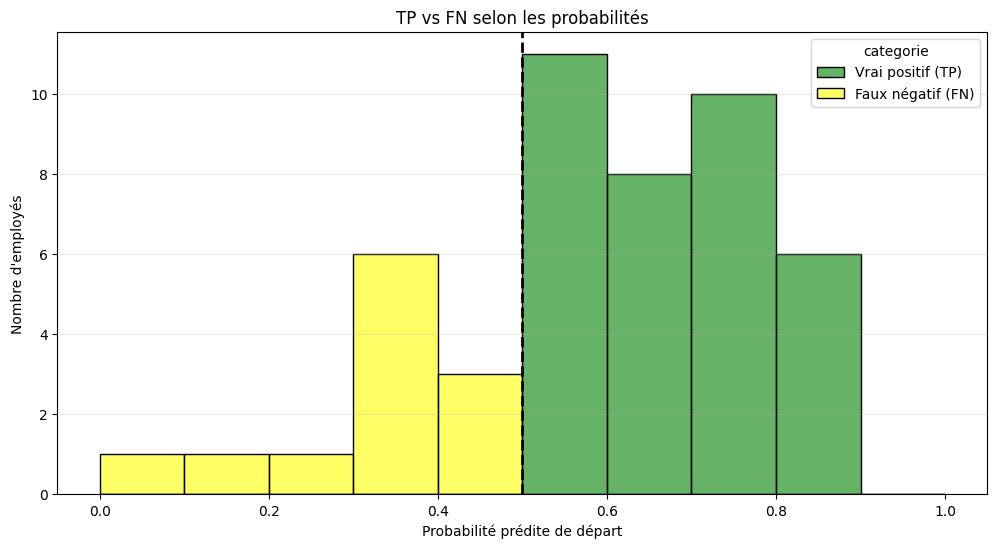

In [79]:
df_fn_tp = df_plot[df_plot["categorie"].isin(["Vrai positif (TP)", "Faux négatif (FN)"])]

plt.figure(figsize=(12,6))

sns.histplot(data=df_fn_tp, x="proba", hue="categorie", bins=np.arange(0, 1.1, 0.1), multiple="layer", palette={"Vrai positif (TP)": "green", "Faux négatif (FN)": "yellow"},alpha=0.6)

plt.axvline(threshold, color="black", linestyle="--", linewidth=2)

plt.xlabel("Probabilité prédite de départ")
plt.ylabel("Nombre d'employés")
plt.title("TP vs FN selon les probabilités")

plt.grid(axis="y", alpha=0.3)
plt.show()

Le modèle attribu globalement de faibles probabilités de départ aux employés qui restent dans l'entreprise. On a néanmoins beaucoup d'employé dits comme partants alors qu'ils restent. Les majorité des vrais départs sont bien détectés avec des probabilités assez élévées.  
On a quelques employés partant non détéctés, donc la probabilité de départ se situe entre 0 et 0,5.  
On a bien un modèle qui priviligie le recall plutot que la précision.  
On peut baisser le seuil pour récupérer quelques départs non détectés, en revanche cela fera encore baisser la précicion en ajoutant beaucoup de faux départs.  

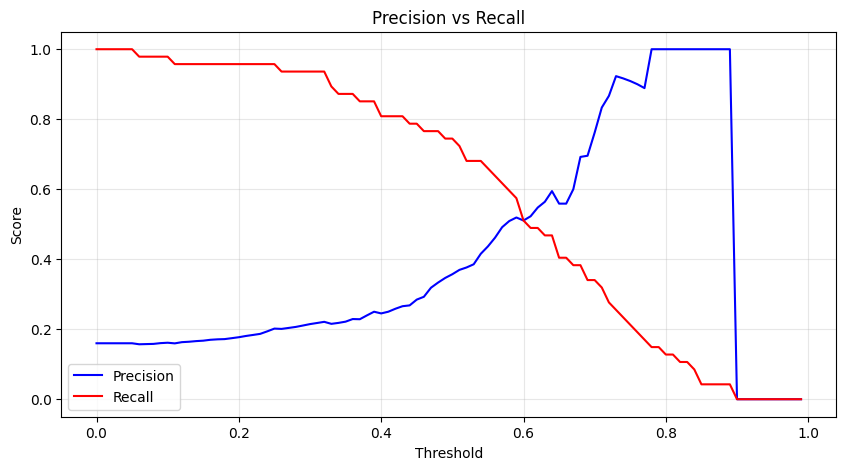

In [80]:
# seuils
thresholds = np.arange(0, 1, 0.01)

# calcul scores
precision = [precision_score(y_test,(y_proba_log >= t).astype(int),zero_division=0)for t in thresholds]

recall = [recall_score(y_test,(y_proba_log >= t).astype(int))for t in thresholds]

# graphique
plt.figure(figsize=(10,5))

plt.plot(thresholds, precision, label="Precision", color="blue")
plt.plot(thresholds, recall, label="Recall", color="red")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Si on abaisse le seuil à 0,4, on obtient un recall d'environ 0,8 (détecte environ 80% des departs), et une precision qui sera aux alentours de 25% (1 employé detecte sur 4 est un vrai départ).  
On fixera le nouveau seuil à 0,4 afin de ne pas trop augmenter les faux départs et ainsi récuprérer la plus grande part des départs initialement non détectés.  
Déterminons la matrice de confusion du modèle avec un seuil de 0,4, et verifions ses performances pour confirmer nos valeurs:

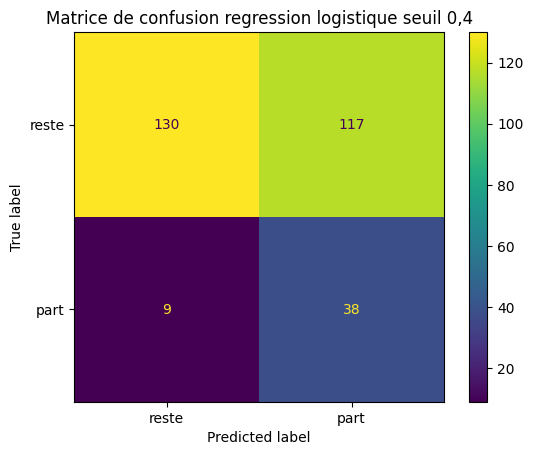

In [81]:
y_pred_log_04 = [ 0 if value < 0.4 else 1 for value in y_proba_log ]
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log_04, display_labels=["reste", "part"])
plt.title("Matrice de confusion regression logistique seuil 0,4")
plt.show()

On observe une nette amélioration du recall, mais également une baisse de la précision.

Evaluons les performances du modèle:

In [82]:
# On récupère les probabilités du modèle sur le train et sur le test
y_train_proba = best_logreg.predict_proba(X_train)[:, 1]
y_test_proba = best_logreg.predict_proba(X_test)[:, 1]

# On fixe le nouveau seuil a 0,4
y_train_pred = (y_train_proba >= 0.4).astype(int)
y_test_pred = (y_test_proba >= 0.4).astype(int)

# On calcul le recall sur le train et le test
train_recall = recall_score(y_train, y_train_pred)
test_recall = recall_score(y_test, y_test_pred)
train_precision = precision_score(y_train, y_train_pred)
test_precision = precision_score(y_test, y_test_pred)

# On met nos résultats dans un tableau
pd.DataFrame({"Dataset": ["Train", "Test"],"Recall": [round(train_recall, 2), round(test_recall, 2)], "precision":[round(train_precision, 2), round(test_precision, 2)]})

,Dataset,Recall,precision
0,Train,0.87,0.27
1,Test,0.81,0.25


Le recall est bien meilleur. les deux valeurs sont relativement proches sur le test et le train donc il n'y a pas de surapprentissage.  
On remarque également que notre précision sur le test est de 25%, donc bien dans la limite que avions fixé.

#### **XGBoost**

On fait de même sur le modèle XGBoost:

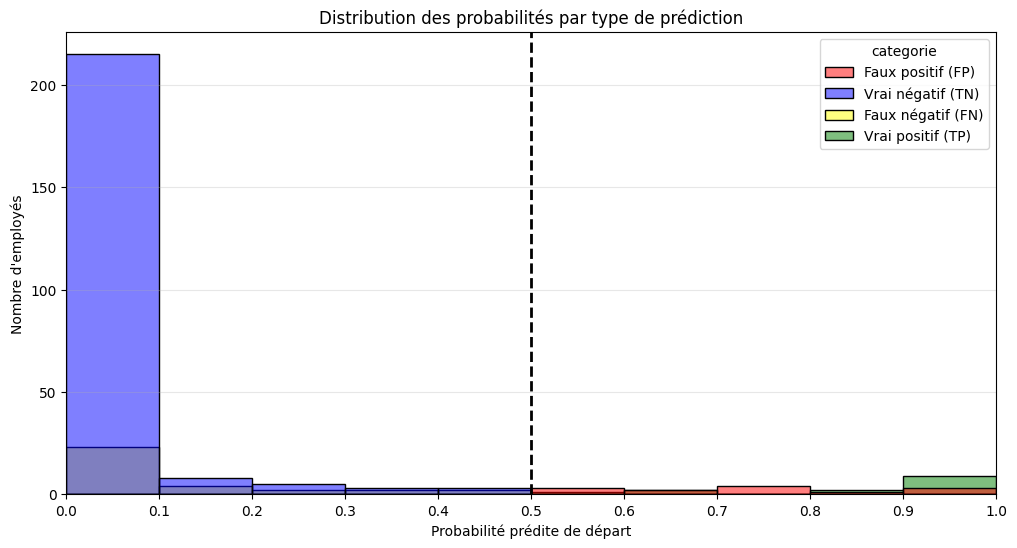

In [83]:
# seuil de classification
threshold = 0.5

# prédictions selon le seuil
y_pred_threshold = (y_proba_xgb >= threshold).astype(int)

# dataframe pour le graphique
df_plot = pd.DataFrame({
    "proba": y_proba_xgb,
    "real": y_test.values,
    "pred": y_pred_threshold
})

# catégories TP / FP / TN / FN
conditions = [
    (df_plot["real"] == 1) & (df_plot["pred"] == 1),  # TP
    (df_plot["real"] == 0) & (df_plot["pred"] == 1),  # FP
    (df_plot["real"] == 0) & (df_plot["pred"] == 0),  # TN
    (df_plot["real"] == 1) & (df_plot["pred"] == 0)   # FN
]

choices = [
    "Vrai positif (TP)",
    "Faux positif (FP)",
    "Vrai négatif (TN)",
    "Faux négatif (FN)"
]

df_plot["categorie"] = np.select(
    conditions,
    choices,
    default="Autre"
)

# couleurs
palette = {
    "Vrai positif (TP)": "green",
    "Faux positif (FP)": "red",
    "Vrai négatif (TN)": "blue",
    "Faux négatif (FN)": "yellow"
}

# graphique
plt.figure(figsize=(12,6))

sns.histplot(
    data=df_plot,
    x="proba",
    hue="categorie",
    bins=np.arange(0, 1.1, 0.1),
    multiple="layer",
    palette=palette,
    alpha=0.5
)

# ligne verticale du seuil
plt.axvline(
    threshold,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Seuil = {threshold}"
)

# mise en forme
plt.xlabel("Probabilité prédite de départ")
plt.ylabel("Nombre d'employés")
plt.title("Distribution des probabilités par type de prédiction")

plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.1))

plt.grid(axis="y", alpha=0.3)

plt.show()

Une proportion importante des employés réellement partis (FN) reçoit des probabilités extrêmement faibles (0–0.1).  
Ces cas sont difficilement distingables des employés ne quittant pas l'entreprise. Donc même en baissant le seuil on fera énormément basser la précicion.  
Le modèle est très sur d'une grande partie des faux négatifs avec des probabilités proche de 0.  
L’ajustement du seuil de décision ne permet pas de récupérer efficacement les faux négatifs, car ceux-ci sont concentrés dans la même zone de probabilité que la majorité des vrais négatifs.  
On ne conservera donc pas ce modèle dans la suite.

Regardons quand même la performance du modèle:

In [84]:
y_train_pred = best_xgb.predict(X_train)
y_test_pred = best_xgb.predict(X_test)

train_recall = recall_score(y_train, y_train_pred)
test_recall = recall_score(y_test, y_test_pred)

pd.DataFrame({"Dataset": ["Train", "Test"],
              "Recall": [round(train_recall, 3), round(test_recall, 3)]})

,Dataset,Recall
0,Train,1.000
1,Test,0.298


On a un ecart très important entre le recall du train et le recall du test donc, le modèle surraprend.  
Ce qui conforte notre choix de rejeter ce modèle au profit de la regression logistique.

Comparons néanmoins nos deux modèles:

In [85]:
results_final = pd.DataFrame([
    {"model": "Logistic Regression (best)",
     "f1": round(f1_score(y_test, y_pred_log_04),2),
     "precision": round(precision_score(y_test, y_pred_log_04),2),
     "recall": round(recall_score(y_test, y_pred_log_04),2),
     "average_precision": round(average_precision_score(y_test, y_proba_log),2)},
    {"model": "XGBoost (best)",
     "f1": round(f1_score(y_test, y_pred_xgb),2),
     "precision": round(precision_score(y_test, y_pred_xgb),2),
     "recall": round(recall_score(y_test, y_pred_xgb),2),
     "average_precision": round(average_precision_score(y_test, y_proba_xgb),2)}])

results_final.sort_values("recall", ascending=False)

,model,f1,precision,recall,average_precision
0,Logistic Regression (best),0.38,0.25,0.81,0.59
1,XGBoost (best),0.38,0.52,0.30,0.51


Le Average_precision de la regression logistique est suppèrieur a celui de XGBoost, c'est donc un meilleur modèle que ce dernier dons notre situation. La regression logistique détecte 81% des départs mais fait beaucoup de faux positifs, avec une précision de seulement 25%, mais qui reste dans les limites fixées, on a donc un modèle plus performant que le hasard.  
XGBoost détecte très peu de départs, ce qui en fait donc globalement un plus mauvais modèle que la régression logistique.  
Ceci confirme notre choix de concerver le modèle de regression logistique plutot que le modèle XGBoost.

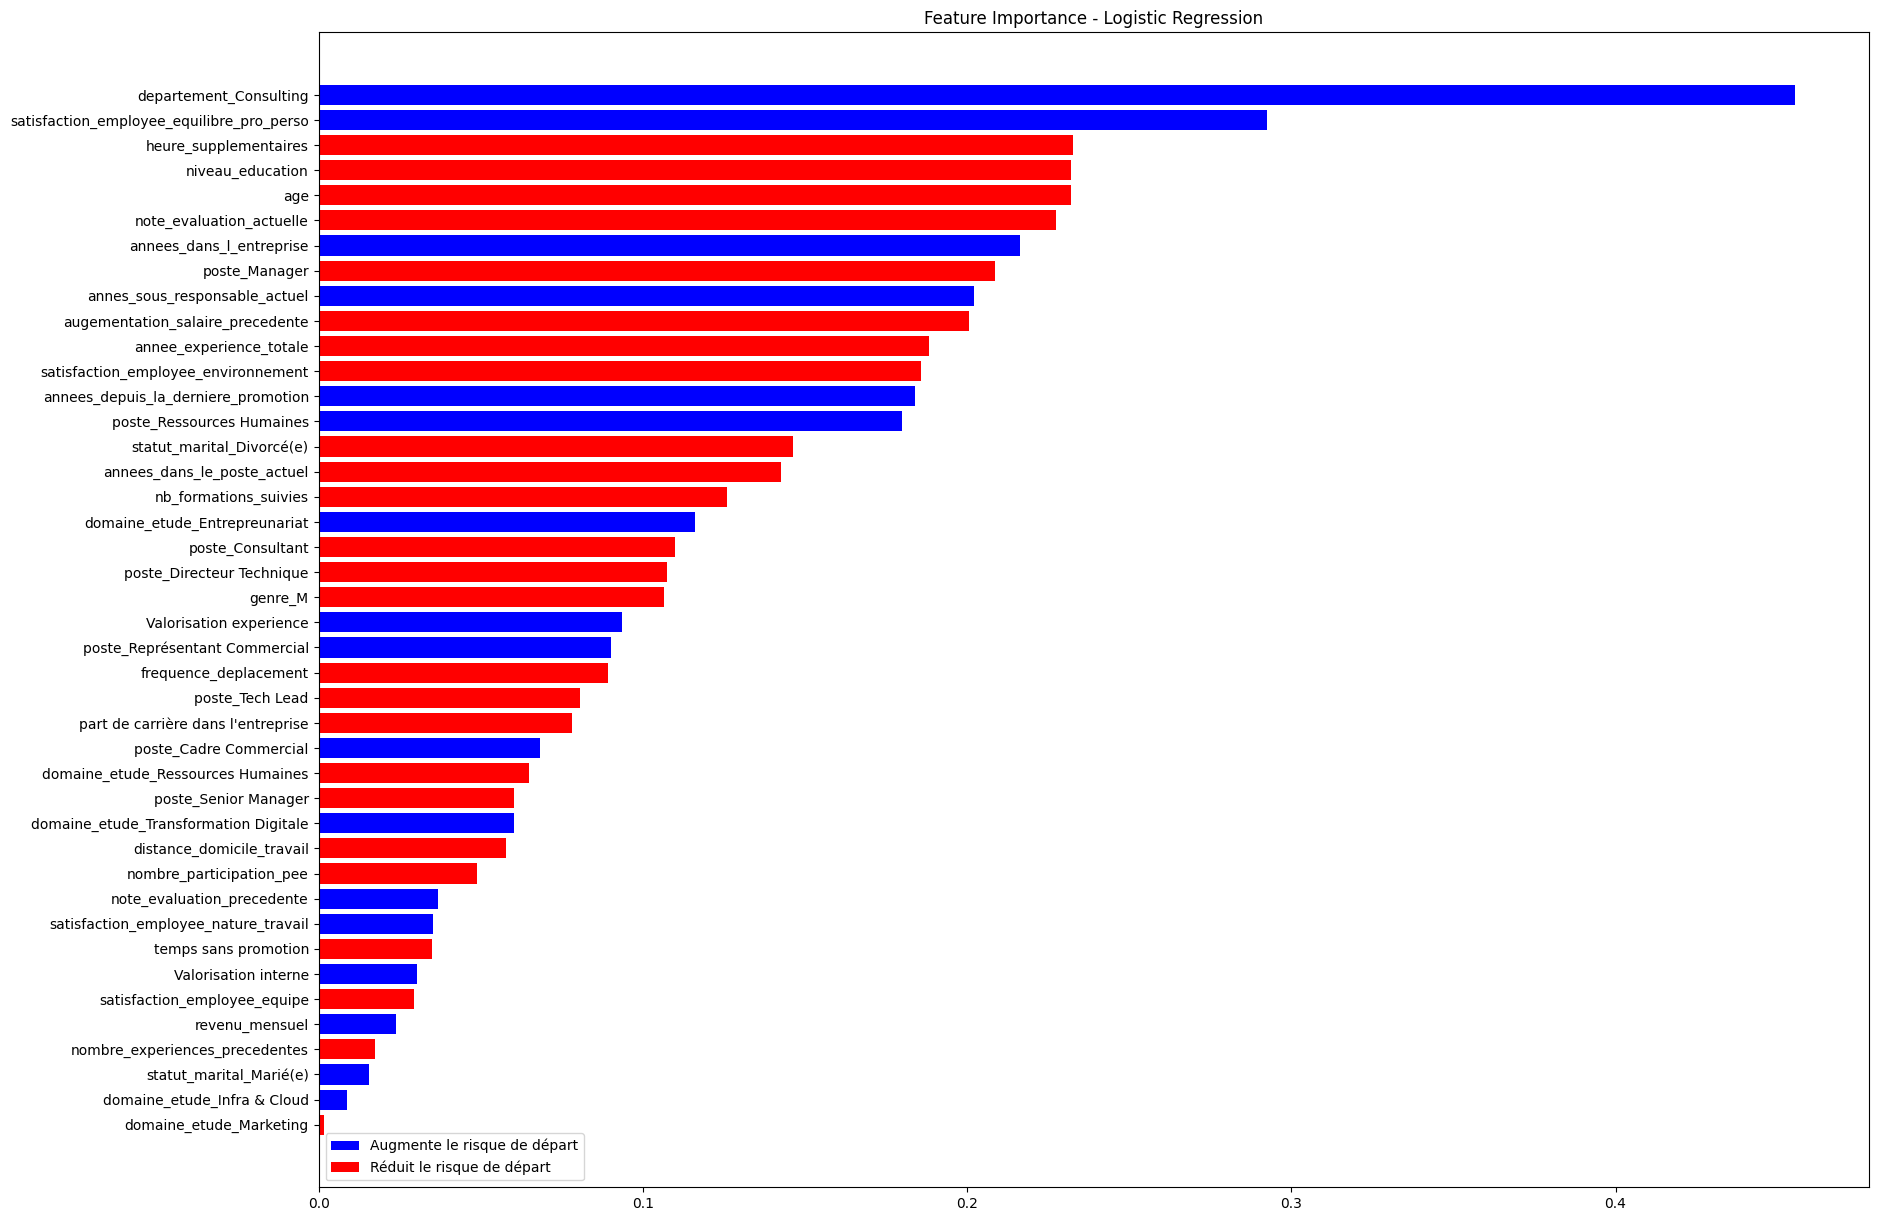

In [86]:
model = best_logreg.named_steps["model"]
coefs = model.coef_[0]

feature_names = X_train.columns

df_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": np.abs(coefs),
    "coef": coefs
}).sort_values("importance", ascending=False)

colors = ["blue" if x > 0 else "red" for x in df_imp["coef"]]

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.figure(figsize=(20,15))

plt.barh(df_imp["feature"], df_imp["importance"], color=colors)
plt.gca().invert_yaxis()

legend_elements = [
    Patch(facecolor="blue", label="Augmente le risque de départ"),
    Patch(facecolor="red", label="Réduit le risque de départ")
]

plt.legend(handles=legend_elements)

plt.title("Feature Importance - Logistic Regression")

plt.show()

Les variables qui influencent le plus le modèle, sont:
- departement_Consulting
- satisfaction_employee_equilibre_pro_perso
- heures supplémentaires
- niveau d’éducation
- âge
- évaluation actuelle
- ancienneté

Les barres représentent l’importance des variables (valeur absolue des coefficients). La couleur indique le sens de l’effet sur la probabilité de départ : bleu pour une augmentation, rouge pour une diminution.  
Le départs semblent en premier lieu liés à la satisfaction, à la charge de travail, ainsi qu'au contexte professionnel.  




Variables associées à une augmentation du risque de départs (barres bleues):  
- certaines fonctions (ressources humaines, consulting, etc.....)
- satisfaction_employee_equilibre_pro_perso
- ancienneté
- années depuis la dernièrepromotion




Variables associées à une diminution du risque de départs (barres bleues)semblent être:  
- heures supplémentaires
- niveau d’éducation
- âge
- évaluation actuelle

Interessons nous aux feature importance de manière locale (pour un individu donné), qui a une forte probabilité de départ et qui est partit.  
On s'interessera a l'individu qui a la plus grande probabilité de partir, et à un second qui a une probabilité de partir se situant aux alentours de 0,7.

In [89]:
# Probabilité prédite de départ
probas = best_logreg.predict_proba(X_test)[:, 1]

# DataFrame avec résultats
results = X_test.copy()

results["Attrition_reelle"] = y_test.values
results["Proba_depart_predite"] = probas

# Afficher uniquement les employés réellement partis
depart_reels = results[results["Attrition_reelle"] == 1]

# Trier par probabilité décroissante
depart_reels = depart_reels.sort_values(by="Proba_depart_predite", ascending=False)

# Affichage
depart_reels[["Proba_depart_predite"]]

,Proba_depart_predite
911,0.894831
357,0.892028
688,0.845246
762,0.840731
1021,0.837347
525,0.811098
514,0.797385
132,0.778618
744,0.760882
711,0.756201


Individu (index pandas) : 2

Probabilité de départ : 0.723


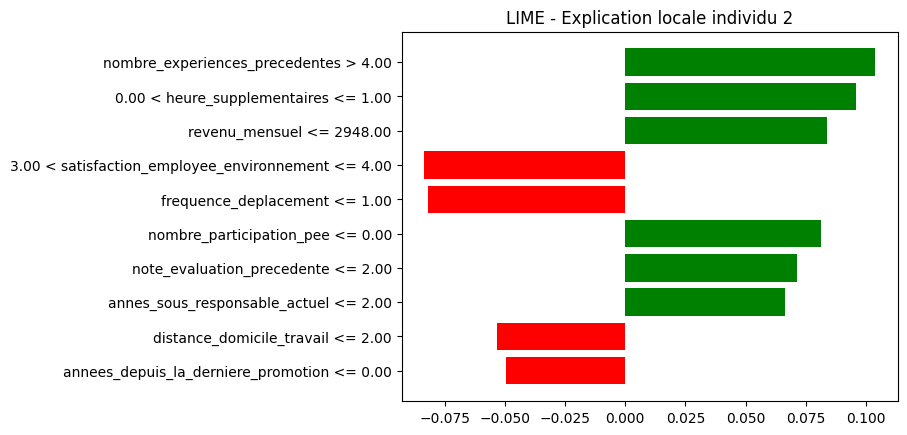

In [91]:
# =========================
# 1. MODELE + DONNÉES
# =========================
model = best_logreg.named_steps["model"]
preprocess = best_logreg.named_steps["preprocessing"]

X_train_df = X_train.copy()
X_test_df = X_test.copy()

# =========================
# 2. INDIVIDU (index pandas = 2)
# =========================
i = 2

x_instance = X_test_df.loc[i]

print("Individu (index pandas) :", i)

# =========================
# 3. WRAPPER
# =========================
def predict_fn(x):
    x_df = pd.DataFrame(x, columns=X_train_df.columns)
    return best_logreg.predict_proba(x_df)

# =========================
# 4. LIME
# =========================
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_df.values,
    feature_names=X_train_df.columns,
    class_names=["Stay", "Leave"],
    mode="classification"
)

exp = explainer.explain_instance(
    data_row=x_instance.values,
    predict_fn=predict_fn,
    num_features=10
)

# =========================
# 5. PROBABILITÉ
# =========================
proba = best_logreg.predict_proba(X_test_df.loc[[i]])[0][1]

print("\nProbabilité de départ :", round(proba, 3))

# =========================
# 6. GRAPHIQUE
# =========================
fig = exp.as_pyplot_figure()
plt.title(f"LIME - Explication locale individu {i}")
plt.show()

On a choisi un individu avec une probabilité de départ de 0.723 (forte mais pas extrèmes). On observe un équilibre entre le nombre de facteurs à risque, et le nombre de facteurs protecteurs.  
Les facteurs qui semblent augmenter les risques de départs sont:  
- Le nombre d'experiences précédentes.
- le fait de faire des heurs supplémentaires
- le revenu mensuel (en dessous de 2948 euros)
- pas de participation aux pee
- note d'évaluation (en dessous ou égale à 2)
- années sous responsable avtuel (infèrieure à deux ans)


Les facteurs qui semblent diminuer les risques de départs sont:
- La satisfaction de l'employé vis à vis de l'environnement de travail
- une faible frequence de déplacement.
- une faible distance entre le domicile et le travail.
- temps entre deux promotions faible.

Individu (index pandas) : 911

Probabilité de départ : 0.895


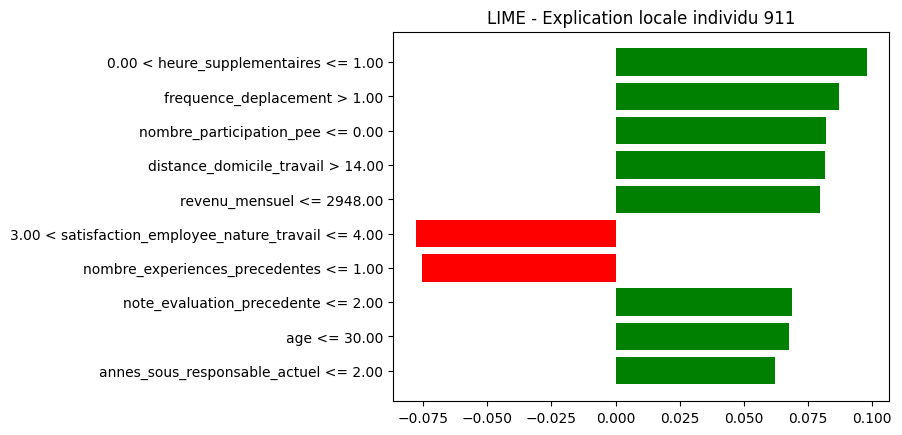

In [92]:
# =========================
# 1. MODELE + DONNÉES
# =========================
model = best_logreg.named_steps["model"]
preprocess = best_logreg.named_steps["preprocessing"]

X_train_df = X_train.copy()
X_test_df = X_test.copy()

# =========================
# 2. INDIVIDU (index pandas = 2)
# =========================
i = 911

x_instance = X_test_df.loc[i]

print("Individu (index pandas) :", i)

# =========================
# 3. WRAPPER
# =========================
def predict_fn(x):
    x_df = pd.DataFrame(x, columns=X_train_df.columns)
    return best_logreg.predict_proba(x_df)

# =========================
# 4. LIME
# =========================
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_df.values,
    feature_names=X_train_df.columns,
    class_names=["Stay", "Leave"],
    mode="classification"
)

exp = explainer.explain_instance(
    data_row=x_instance.values,
    predict_fn=predict_fn,
    num_features=10
)

# =========================
# 5. PROBABILITÉ
# =========================
proba = best_logreg.predict_proba(X_test_df.loc[[i]])[0][1]

print("\nProbabilité de départ :", round(proba, 3))

# =========================
# 6. GRAPHIQUE
# =========================
fig = exp.as_pyplot_figure()
plt.title(f"LIME - Explication locale individu {i}")
plt.show()

On s'intéresse ici à l'individu parti avec la plus grande probabilité de départ (0,895). On observe beaucoup plus de facteurs à risque:  
- heures supplémentaires.
- plus grande frequence de déplacement
- nombre de participation au pee
- une distance entre le domicile et le travail de plus de 14 km
- revenu mensuel en dessous de 2948 euros
- une evaluation precedente endessous de 2
- un age en dessous de 30 ans
- nombre d'années sous responsable actuel infèrieur a deux ans



les facteurs protecteurs sont:
- le nombre d'experiences precedentes faible.
- la satisfaction de l'employé vis à vis de la nature de son travail

## Conclusion

Dans le cadre de la demande RH, nous avons entraîné un modèle logistique pouvant aider à prédire si un employé risque de quitter l'entreprise.  
Ce modèle permet détecte environs 81% des départs avec une précision de 25% (1 employé su 4 prédit quitte réellement l'entreprise).  
Le modèle permet d'identifier les employés à risques, et une étude des features importance,locale permet de mettre en évidence les facteurs influents augmentant les risques de départs comme la charge de travail, la rémunération, la satisfaction, ou les conditions de déplacement. Ces résultats permettent de donner des pistes d'actions concrètes pour les ressources humaines telles que la réduction des heures supplémentaires, l'amélioration des conditions de travail, et l'adaptation
 des politiques de rémunérations.